# Lichess Chess Game Analysis — Complete Pipeline (Full Dataset)

**Dataset:** Lichess Standard Rated Games — February 2026 (`lichess_db_standard_rated_2026-02.pgn`, ~185GB, ~84.6M games)

This is the third and final notebook in this project, consolidating `chess_mining_pipeline.ipynb` (ingestion through descriptive statistics) and `chess_final_analysis.ipynb` (sequence mining and predictive modeling) into one pipeline meant to be run **once, end to end, against the complete dataset**. Earlier work validated every method here at a 50,000-game sample; this notebook carries the same methods forward at full scale rather than introducing anything new.

**Structure:**
- **Part I (Sections 0-4)** — data ingestion, cleaning, feature engineering, and descriptive statistics. Adapted from `chess_mining_pipeline.ipynb`.
- **Part II (Sections 5-10)** — move-sequence pattern mining, rating-level breakdown, and predictive modeling, including a real-time-style checkpoint model. Adapted from `chess_final_analysis.ipynb`.

**A structural change from the two source notebooks:** each of them parsed the raw PGN file independently -- the pipeline notebook once for its 6-ply opening features, `chess_final_analysis.ipynb` a second time for full, uncapped move sequences (and an earlier draft of the pipeline notebook parsed a *third* time for a since-removed "beyond the opening" pass). At full scale, reading a 185GB file even twice is a large, avoidable cost. This notebook parses the PGN **exactly once** (Section 1): the single pass captures both the header/opening-move fields Part I needs and the complete move list Part II needs, and Part II reuses that same in-memory table directly instead of re-parsing or reloading from disk.

---
## Chess Terminology Primer

If you don't play chess, here are the terms and abbreviations used throughout this notebook.

**Notation formats**
- **PGN (Portable Game Notation)** — the plain-text file format the raw dataset comes in. Each game is a block of header tags (`[WhiteElo "1696"]`, etc.) followed by the list of moves.
- **SAN (Standard Algebraic Notation)** — how individual moves are written, e.g. `e4`, `Nf3`, `O-O`. This is what ends up in the `ply_1` … `ply_6` columns.
  - Piece letters: `K` king, `Q` queen, `R` rook, `B` bishop, `N` knight. A move with no letter (e.g. `e4`, `d5`) is a pawn move.
  - `x` = capture (e.g. `Nxd5`), `+` = check, `#` = checkmate.
  - `O-O` = castling kingside, `O-O-O` = castling queenside.

**Moves**
- **Ply / half-move** — one move by one player. A "full move" is White's move plus Black's reply; a ply is just one side's move. `ply_1` is White's first move, `ply_2` is Black's first reply, and so on. This notebook only keeps the first `K_MOVES` plies (the opening) of each game.

**Ratings and outcome**
- **Elo rating** (`white_elo`, `black_elo`) — a numeric skill rating; higher means a stronger player. `rating_diff` is White's rating minus Black's.
- **Result** — recorded as `1-0` (White won), `0-1` (Black won), or `1/2-1/2` (draw); the notebook relabels these as `white_win`, `black_win`, `draw`.
- **Termination** — how the game ended: `Normal` (checkmate/resignation), `Time forfeit` (a player ran out of the clock), or `Abandoned`.

**Time control**
- **Time control** (e.g. `60+0`) — written as `base+increment` in seconds: starting clock time, plus seconds added per move. `60+0` means 60 seconds total with no increment.
- Derived category (`tc_cat`) based on estimated total game time: **Bullet** (< 3 min), **Blitz** (3–10 min), **Rapid** (10+ min), **Classical** (slower, longer games).

**Openings**
- **Opening** — the named sequence of early moves a game follows (e.g. "Caro-Kann Defense: Advance Variation"), analogous to a recognized playbook of first moves.
- **ECO code** — a short code (e.g. `B12`) from the *Encyclopaedia of Chess Openings* classifying the opening. The first letter (`eco_family`, A–E) groups openings into broad families: A = flank openings, B = semi-open games, C = open games, D = closed games, E = Indian defenses.

---
## Methodology Evolution

The deep-dive methods in Part II went through several rounds of revision before arriving at their current form. Each change was driven by a concrete finding, not a stylistic preference -- summarized here so the reasoning behind Part II's design is visible in one place, rather than only scattered through each section's own notes.

1. **Position-tagged association rules -> position-free contiguous sequences.** The first approach (still present in `chess_mining_pipeline.ipynb`'s Section 5, not carried into this notebook) tagged every move with its exact move number (`w4:Nf3`), so a pattern only matched if it occurred at that precise point in the game. That ceiling topped out around lift 1.06 and required mining with `mlxtend`'s Apriori implementation, which had already caused a memory crash once during development and remains a real risk at full scale -- a "beyond the opening" follow-up pass mined 4-ply sliding windows and mostly just re-found the same weak opening-only signal. Section 5 below replaces both with contiguous n-gram mining over each game's full, position-free move sequence, which found materially stronger and more chess-recognizable patterns (e.g. named tactical lines) at a fraction of the mining cost.
2. **Per-color sequences -> combined, interleaved sequences.** An early version of Section 5 mined each side's own moves in isolation, on the reasoning that a "White pattern" should reflect White's own choices independent of the opponent's replies. That version consistently found weaker signal than mining the combined, interleaved sequence of both sides' actual moves -- unsurprising in hindsight, since chess is fundamentally reactive and a sequence that ignores the opponent's replies discards real information. Section 5 now works only with the combined sequence.
3. **Opening-only, three-outcome rule mining -> one unified full-game pass.** `white_win`/`black_win` sequence mining and `draw` sequence mining were originally two separate passes at two different scopes (the latter restricted to the opening window). They're now the same one-vs-rest contiguous n-gram method, over the same full-game sequence, for all three outcomes at once (Section 5) -- simpler, and it let a real, strong draw-associated pattern emerge that the earlier opening-only pass had missed entirely.
4. **A single fixed early-game checkpoint -> a full per-10-ply checkpoint panel.** The first predictive model beyond pre-game features checked for pattern presence within one arbitrary early-ply window. The current version (Section 8) instead builds a panel with one row per game per 10-ply checkpoint (ply 10, 20, 30, ... up to the last checkpoint before that game ends), letting prediction accuracy be tracked as a genuine function of how much of the game has been observed, rather than at one arbitrary snapshot.
5. **Game-level modeling -> player-level modeling.** The predictive models originally had one row per game and predicted `white_wins` directly, with rating difference signed around White. That meant any advantage from simply *being* White was invisible, absorbed silently into the model's intercept. Section 7 restructures to one row per *player* (each game contributes a White-perspective row and a mirrored Black-perspective row), which makes `color` a real, separately estimable feature -- and confirms White's edge is real, small, and independent of rating.
6. **Sequence deduplication.** Contiguous n-gram mining at multiple lengths (6/8/10 plies) surfaces many nested duplicates (an 8-ply pattern that's just a 6-ply pattern with two more moves appended) and, less obviously, sequences that are exact color-flipped mirrors of each other ranking highly under different outcomes. Section 8 deduplicates both before selecting the patterns used as model features, rather than letting near-identical sequences crowd out distinct ones.
7. **Full 84.6M-game run -> a random 15M-game sub-sample.** The original plan was to run this notebook against the complete month (84.6M games) on rented cloud hardware. That plan surfaced two real blockers once actually pursued, neither of them about the analysis code itself:
   - **Memory.** Even after redesigning Section 8's checkpoint panel to avoid materializing it all at once, and after fixing a separate memory issue in how move sequences were stored (both described above and below), full scale is still estimated at roughly **~120GB of peak RAM** -- more than a typical personal computer has, and more than the smallest tiers a brand-new cloud account can access without a support-approved resource-limit increase (a standard anti-fraud practice on every major cloud provider, not specific to one).
   - **Cost and availability.** Cloud instances with enough RAM to comfortably clear that ~120GB estimate cost real money per hour and, for a new account, may not even be selectable until a support request is approved -- an unpredictable amount of both money and waiting for what is a course project, not a production system.

   Rather than spend that money and wait on that approval just to prove the complete dataset runs, this notebook uses a **truly random sample of 15 million games** -- about 100-200x larger than the 50,000-game sample used throughout development, but small enough to run **entirely on a personal computer with 32GB of RAM, in a few hours, at no cost.** Games are drawn by picking random *byte positions* scattered across the entire file and taking whichever game starts there (`random_sample_parse_pgn` in `src/ingestion/pgn_parser.py`), rather than reading the first N games in file order -- so the sample reflects a genuine cross-section of the whole month (different times of day, different event types, no bias toward whatever happened to be played earliest), not just its opening slice.

   This directly reverses the note below, which was written earlier in this notebook's development and assumed random sampling would require a full sequential scan of the ~185GB file to draw a sample -- slow enough that it wasn't judged worth the cost at the time. The random-byte-position approach avoids that scan entirely: it touches only the (small number of) games actually drawn, not the whole file, which is what makes a genuinely random sample practical after all.

   *(Original note, kept for the record of how this decision evolved: "One thing that was considered and not changed: game sampling. Both source notebooks (and this one) sample the first N_SAMPLE games in file order rather than a random subset. A true random sample across the full ~84.6M-game file would require a one-pass scan of the entire 185GB file just to draw the sample -- a cost judged not worth paying for this project's scope. That's a standing limitation of every result in this notebook, carried forward rather than resolved." -- superseded by point 7 above.)*

   One honest technical caveat about the random-sampling method itself: picking a uniformly-random byte position and taking "the next game found" means a game's chance of being selected is weighted very slightly by how much file space precedes it (roughly, how long the *previous* game was), rather than being a mathematically exact uniform sample by game count. At this sample size the effect is small, but it's a real approximation worth naming rather than glossing over.

---
## Part I: Data Pipeline

---
## Section 0: Setup and Configuration

In [1]:
# Install packages not in the base environment
# python-chess: PGN parsing
%pip install python-chess -q

Note: you may need to restart the kernel to use updated packages.


In [2]:
## Install all packages in requirements.txt
%pip install -r requirements.txt -q

## Import necessary libraries
import os
import re
import sys
import gc
import time
import subprocess
import warnings

# Data manipulation and visualization
import chess.pgn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

# Machine learning libraries
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve
)

# Suppress warnings and set visualization theme
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
%matplotlib inline

# Check if all imports were successful
print('All imports successful.')

ERROR: Could not open requirements file: [Errno 2] No such file or directory: 'requirements.txt'


Note: you may need to restart the kernel to use updated packages.
All imports successful.


In [3]:
# ── Paths ──────────────────────────────────────────────────────────────────
BASE_DIR   = os.path.abspath('..')   # notebooks/ -> project root
RAW_PGN    = os.path.join(BASE_DIR, 'data', 'raw',       'lichess_db_standard_rated_2026-02.pgn')
INTERIM    = os.path.join(BASE_DIR, 'data', 'interim')
PROCESSED  = os.path.join(BASE_DIR, 'data', 'processed')
sys.path.insert(0, BASE_DIR)

# ── Pipeline parameters ────────────────────────────────────────────────────
# PARSE_MODE picks how many games get parsed and how they're chosen:
#   'dev_sample' -- first N_DEV_SAMPLE games, sequential, run directly in this
#                   kernel (no multiprocessing, so no crash risk -- see below).
#                   Fast; used only for iterating on the analysis itself.
#   'random'     -- a truly random cross-section of N_RANDOM_SAMPLE games,
#                   scattered across the WHOLE file by byte position rather
#                   than file order. This is the mode this notebook's actual
#                   results come from -- see the Methodology Evolution note
#                   above for why (full-scale RAM and cloud-cost/availability
#                   constraints ruled out the complete dataset for this
#                   project's scope).
#   'full'       -- every game in the file. Needs an estimated ~120GB of RAM
#                   at full scale -- more than most personal computers have,
#                   and more than the smallest tiers a new cloud account can
#                   access without a support-approved limit increase.
#
# 'random' and 'full' both use multiprocessing.Pool, which runs as a
# standalone subprocess (src/ingestion/run_parse.py) rather than directly in
# this notebook's kernel -- see the Section 1 methodology note for why: doing
# it in-kernel was found to crash the kernel outright on Windows (a ZMQ/
# networking resource conflict between the kernel's own communication
# channels and the worker processes).
PARSE_MODE      = 'random'
N_DEV_SAMPLE    = 50_000       # games for PARSE_MODE='dev_sample'
N_RANDOM_SAMPLE = 5_000_000    # games for PARSE_MODE='random' -- a 15M attempt OOM'd on this 32GB machine; 5M is the tested-safe target after the interning fix below (see Section 1)
RANDOM_SEED     = 42           # reproducibility for both random sampling and modeling
K_MOVES         = 6            # half-moves (plies) used later for opening-only features

# Parallel workers (PARSE_MODE='random' or 'full' only -- 'dev_sample' is
# small enough that parallelizing isn't worth the overhead). 8 was the
# fastest worker count benchmarked on 6 physical/12 logical local cores (4.5x
# over sequential; 12 workers was SLOWER due to hyperthreading contention) --
# re-benchmark this on whatever machine actually runs the parse, since the
# right number depends on physical core count, not just however many vCPUs
# the OS reports.
N_WORKERS = 8

# ── Validate paths ─────────────────────────────────────────────────────────
assert os.path.exists(RAW_PGN),   f'PGN not found: {RAW_PGN}'
assert os.path.isdir(INTERIM),    f'Interim dir missing: {INTERIM}'
assert os.path.isdir(PROCESSED),  f'Processed dir missing: {PROCESSED}'

pgn_gb = os.path.getsize(RAW_PGN) / 1e9
print(f'PGN file:    {RAW_PGN}')
print(f'PGN size:    {pgn_gb:.1f} GB')
print(f'Parse mode:  {PARSE_MODE}')
if PARSE_MODE == 'dev_sample':
    print(f'  N = {N_DEV_SAMPLE:,} (first N games, file order)')
elif PARSE_MODE == 'random':
    print(f'  N = {N_RANDOM_SAMPLE:,} (random cross-section, {N_WORKERS} workers, standalone subprocess)')
else:
    print(f'  N = ALL ({N_WORKERS} workers, standalone subprocess)')
print(f'Plies/game (opening-feature cutoff): {K_MOVES}')

PGN file:    c:\Users\User\OneDrive\Documents\CSPB4502\DataMiningProject\data\raw\lichess_db_standard_rated_2026-02.pgn
PGN size:    197.7 GB
Parse mode:  random
  N = 5,000,000 (random cross-section, 8 workers, standalone subprocess)
Plies/game (opening-feature cutoff): 6


---
## Section 1: Data Ingestion and PGN Parsing

### 1.1 PGN Format

PGN (Portable Game Notation) is a plain-text chess game format. Each game consists of a **header block** of bracketed tag-value pairs followed by a **movetext** block. Example:

```
[Event "Rated Bullet game"]
[WhiteElo "1696"]
[BlackElo "1617"]
[ECO "B12"]
[Opening "Caro-Kann Defense: Advance Variation"]
[TimeControl "60+0"]
[Result "1-0"]
[Termination "Time forfeit"]

1. e4 { [%clk 0:01:00] } 1... c6 { [%clk 0:01:00] } 2. d4 ...
```

The `python-chess` library handles PGN parsing, converting movetext into Standard Algebraic Notation (SAN) moves (e.g., `e4`, `Nf3`, `O-O`).

### 1.2 Parsing Strategy

Loading the full ~198GB file into memory at once is not feasible, so `PARSE_MODE` controls how many games get parsed and how they're chosen (see the Methodology Evolution note above for the full reasoning):

- **`'dev_sample'`** -- the first `N_DEV_SAMPLE` games, parsed sequentially. Fast and deterministic; used only for iterating on the analysis itself, not for real results.
- **`'random'`** -- a truly random cross-section of `N_RANDOM_SAMPLE` games, scattered across the *entire* file by byte position rather than file order (`random_sample_parse_pgn`). **This is the mode this notebook's actual results come from.**
- **`'full'`** -- every game in the file, parsed in parallel byte-range chunks (`parallel_parse_pgn`). Needs an estimated ~120GB of RAM at full scale -- more than most personal computers have.

**A subprocess, not the kernel, does the actual parallel parsing.** `'random'` and `'full'` both use `multiprocessing.Pool` to parse with several worker processes at once. The first real attempt at the 15-million-game random run crashed outright partway through -- not a bug in the parsing logic, but a Windows-specific resource conflict: the multiprocessing workers and this notebook's own Jupyter kernel both rely on inter-process communication, and running 8 extra worker processes alongside the kernel's own channels exhausted a Windows networking resource (`WSAENOBUFS`, "No buffer space available", surfacing deep inside the kernel's ZMQ networking library) and took the whole kernel down with it. The fix: `src/ingestion/run_parse.py` runs the actual parsing as an ordinary standalone subprocess, entirely outside this notebook's kernel, and saves its result to `data/interim/games_raw_<mode>.parquet`; this cell just launches that subprocess, streams its progress live, and loads the parquet it produces once done. If that cache file already exists, this cell skips straight to loading it -- so re-running this cell after a completed parse doesn't reparse from scratch.

For each game, the following are extracted:
- All header metadata (ratings, ECO, opening, time control, result, termination)
- Total ply count (full walk of mainline moves)
- The full move list in SAN format -- not just the opening, since Part II's pattern mining needs the whole game

In [4]:
def classify_time_control(tc):
    """
    Map a Lichess time-control string ('base+increment') to a category.

    Lichess records dozens of distinct base+increment combinations
    (e.g. '60+0', '180+2', '600+0'), which is too granular to group on
    directly. Bucketing into bullet/blitz/rapid/classical gives later
    sections (outcome rates, ratings, openings) a small set of
    meaningful categories to compare instead.
    """
    # PGN's TimeControl header is '?' or '-' when no clock was used (e.g. correspondence).
    if not tc or tc in ('?', '-'):
        return 'unknown'
    try:
        # TimeControl is 'base+increment' in seconds (e.g. '180+2' = 3 min + 2s/move).
        # A bare number with no '+' means zero increment.
        if '+' in tc:
            base_s, incr_s = (int(x) for x in tc.split('+', 1))
        else:
            base_s, incr_s = int(tc), 0
        # Estimated total time: base + 40 moves * increment (FIDE convention).
        # Increment adds up over the course of a game, so raw base time alone
        # would misclassify, e.g., a slow-increment game as faster than it plays.
        estimated = base_s + 40 * incr_s
        # Thresholds mirror Lichess's own bullet/blitz/rapid/classical cutoffs.
        if estimated < 180:
            return 'bullet'
        elif estimated < 600:
            return 'blitz'
        elif estimated < 1800:
            return 'rapid'
        return 'classical'
    except Exception:
        # Guards against malformed/unexpected TimeControl strings so one bad
        # row doesn't crash parsing of the whole batch.
        return 'other'

In [5]:
def parse_pgn(pgn_path, n_games=None):
    """
    Stream-parse a PGN file into a DataFrame, one row per game.

    A single pass extracts everything both Part I (header fields, opening
    moves, descriptive stats) and Part II (full move-sequence mining) need --
    header metadata, total ply count, and the COMPLETE move list, not just
    the opening. Parsing the ~185GB source file is by far the most expensive
    step in this notebook; the two source notebooks this one consolidates
    each parsed it independently, and an earlier draft of the pipeline
    notebook parsed it a third time for a since-removed analysis. Doing it
    once here removes that duplicated cost entirely.

    Parameters
    ----------
    pgn_path : str   Path to the (already decompressed) PGN file.
    n_games  : int   Stop after this many games (None = parse all).

    Returns
    -------
    pd.DataFrame  One row per game, with a `moves` column holding the full
                  SAN move list (used by Part II) alongside the header fields
                  and `num_plies` (used by Part I).
    """
    records = []
    t0 = time.time()

    with open(pgn_path, encoding='utf-8', errors='replace') as pgn:
        idx = 0
        while (n_games is None) or (idx < n_games):
            game = chess.pgn.read_game(pgn)
            if game is None:
                break

            h = game.headers
            board = game.board()
            moves = []
            for mv in game.mainline_moves():
                moves.append(board.san(mv))
                board.push(mv)

            records.append({
                'game_id':           idx,
                'event':             h.get('Event',           '?'),
                'result':            h.get('Result',          '?'),
                'utc_date':          h.get('UTCDate',         '?'),
                'white_elo':         h.get('WhiteElo',        '?'),
                'black_elo':         h.get('BlackElo',        '?'),
                'white_rating_diff': h.get('WhiteRatingDiff', '?'),
                'black_rating_diff': h.get('BlackRatingDiff', '?'),
                'eco':               h.get('ECO',             '?'),
                'opening':           h.get('Opening',         '?'),
                'time_control':      h.get('TimeControl',     '?'),
                'termination':       h.get('Termination',     '?'),
                'num_plies':         len(moves),
                'moves':             moves,
            })
            idx += 1

            if idx % 10_000 == 0:
                elapsed = time.time() - t0
                print(f'  {idx:>10,}  |  {elapsed:.0f}s  |  {idx / elapsed:,.0f} games/s')

    elapsed = time.time() - t0
    print(f'Done: {idx:,} games in {elapsed:.1f}s  ({idx / elapsed:,.0f} games/s)')
    return pd.DataFrame(records)

In [6]:
if PARSE_MODE == 'dev_sample':
    print(f'Parsing first {N_DEV_SAMPLE:,} games from PGN (single pass, sequential, in-kernel -- '
          f'no multiprocessing involved, so no subprocess needed here) ...\n')
    df_raw = parse_pgn(RAW_PGN, n_games=N_DEV_SAMPLE)

else:
    # 'random' and 'full' both use multiprocessing.Pool. Running that directly
    # in this notebook's own Jupyter kernel was found to crash the kernel
    # outright on Windows (multiprocessing workers + the kernel's own ZMQ
    # communication channels exhausted a Windows networking resource mid-run).
    # Delegating to a standalone subprocess avoids that: the heavy Pool lives
    # entirely in an ordinary child process, never alongside a live kernel.
    raw_cache_path = os.path.join(INTERIM, f'games_raw_{PARSE_MODE}.parquet')

    if os.path.exists(raw_cache_path):
        print(f'Loading previously-parsed data from {raw_cache_path} ...\n')
        df_raw = pd.read_parquet(raw_cache_path)
    else:
        run_parse_script = os.path.join(BASE_DIR, 'src', 'ingestion', 'run_parse.py')
        if PARSE_MODE == 'random':
            print(f'Parsing a random cross-section of {N_RANDOM_SAMPLE:,} games from PGN, '
                  f'as a standalone subprocess ({N_WORKERS} parallel workers, scattered '
                  f'across the whole file by byte position -- not the first N games in '
                  f'file order) ...\n')
            cmd = [sys.executable, '-u', run_parse_script, 'random', RAW_PGN, raw_cache_path,
                   str(N_RANDOM_SAMPLE), str(N_WORKERS), str(RANDOM_SEED)]
        else:
            print(f'Parsing ALL games from PGN, as a standalone subprocess '
                  f'({N_WORKERS} parallel workers) ...\n')
            cmd = [sys.executable, '-u', run_parse_script, 'full', RAW_PGN, raw_cache_path,
                   str(N_WORKERS)]

        process = subprocess.Popen(cmd, stdout=subprocess.PIPE, stderr=subprocess.STDOUT,
                                    text=True, bufsize=1)
        for line in process.stdout:
            print(line, end='')
        process.wait()
        if process.returncode != 0:
            raise RuntimeError(f'Parsing subprocess failed (exit code {process.returncode}) -- '
                                f'see the output above for the actual error.')
        df_raw = pd.read_parquet(raw_cache_path)

print(f'\nRaw DataFrame shape: {df_raw.shape}')

Parsing a random cross-section of 5,000,000 games from PGN, as a standalone subprocess (8 parallel workers, scattered across the whole file by byte position -- not the first N games in file order) ...

  ... still sampling (1.0 min elapsed)
  ... still sampling (2.0 min elapsed)
  ... still sampling (3.0 min elapsed)
  ... still sampling (4.0 min elapsed)
  ... still sampling (5.0 min elapsed)
  ... still sampling (6.0 min elapsed)
  ... still sampling (7.0 min elapsed)
  ... still sampling (8.0 min elapsed)
  ... still sampling (9.0 min elapsed)
  ... still sampling (10.0 min elapsed)
  ... still sampling (11.0 min elapsed)
  ... still sampling (12.0 min elapsed)
  ... still sampling (13.0 min elapsed)
  ... still sampling (14.0 min elapsed)
  ... still sampling (15.0 min elapsed)
  ... still sampling (16.0 min elapsed)
  ... still sampling (17.0 min elapsed)
  ... still sampling (18.0 min elapsed)
  ... still sampling (19.0 min elapsed)
  ... still sampling (20.0 min elapsed)
  ... s

In [7]:
# -- Memory optimization: intern move tokens ---------------------------------
# The SAN move vocabulary is small (a few thousand distinct tokens: 'e4', 'Nf3',
# 'Qxd8+', ...) but python-chess mints a brand-new string object every time
# board.san() is called, so an un-interned moves column allocates one object
# per ply per game even though the same tokens repeat across millions of games.
# Interning collapses that to one shared object per unique token -- this is
# where most of the moves-list memory actually goes at multi-million-game
# scale (Section 5 measured the equivalent color-tagged structure at ~3,776
# bytes/game un-interned vs ~725 bytes/game interned, a 5.2x difference).
#
# run_parse.py's workers already intern while parsing, but worker-side
# interning doesn't survive the pickle round trip back to this process (each
# process keeps its own intern table), and a fresh pd.read_parquet() load
# never interns at all -- so this pass is needed here regardless of which
# PARSE_MODE produced df_raw, and regardless of whether it came from a fresh
# parse or a cached parquet file.
df_raw['moves'] = df_raw['moves'].apply(lambda ms: [sys.intern(m) for m in ms])
print(f"Interned 'moves' tokens for {len(df_raw):,} games.")

Interned 'moves' tokens for 5,000,000 games.


In [8]:
print('Column overview:')
print(df_raw.dtypes)
print()
df_raw.head(3)

Column overview:
game_id               int64
event                   str
result                  str
utc_date                str
white_elo               str
black_elo               str
white_rating_diff       str
black_rating_diff       str
eco                     str
opening                 str
time_control            str
termination             str
num_plies             int64
moves                object
dtype: object



,game_id,event,result,utc_date,white_elo,black_elo,white_rating_diff,black_rating_diff,eco,opening,time_control,termination,num_plies,moves
0,0,Rated Bullet game,1-0,2026.02.05,1831,1848,+6,-6,A00,Hungarian Opening: Symmetrical Variation,60+0,Normal,65,"[g3, g6, d3, Bg7, Bg2, d6, c3, e5, Qb3, Nc6, B..."
1,1,Rated Blitz tournament https://lichess.org/tou...,0-1,2026.02.10,1659,1741,-5,+4,C21,Center Game Accepted,180+0,Normal,54,"[e4, e5, d4, exd4, c4, Nc6, Bd3, Bb4+, Bd2, Bx..."
2,2,Rated Bullet game,1-0,2026.02.05,1278,1374,+7,-7,A00,Hungarian Opening: Dutch Defense,60+0,Normal,55,"[g3, f5, Bg2, Nf6, d3, g6, c4, Bg7, Nc3, d6, B..."


In [9]:
raw_path = os.path.join(INTERIM, 'games_raw.parquet')
df_raw.to_parquet(raw_path, index=False)
size_mb = os.path.getsize(raw_path) / 1e6
print(f'Saved: {raw_path}  ({size_mb:.1f} MB)')
print('(Larger than the pipeline-only version of this file -- it now carries the full move list, not just the first K_MOVES plies.)')

Saved: c:\Users\User\OneDrive\Documents\CSPB4502\DataMiningProject\data\interim\games_raw.parquet  (670.5 MB)
(Larger than the pipeline-only version of this file -- it now carries the full move list, not just the first K_MOVES plies.)


---
### Section 1 Recap

*To fill in after the full-dataset run:*
- Total games parsed, wall-clock time, and games/second throughput at full scale (compare to the ~50K-game sample rate to sanity-check parsing didn't degrade non-linearly).
- Confirm `games_raw.parquet` file size is reasonable and the `moves` column round-trips correctly through parquet at this scale.
- Note any new header-field irregularities that only show up at full scale (e.g. additional `Termination` values, missing headers) not seen in the sample.

---
## Section 2: Data Cleaning

### Cleaning Steps

| Step | Action |
|---|---|
| Type conversion | Parse `white_elo` / `black_elo` to integers; coerce invalid strings to `NaN` |
| Missing metadata | Drop games missing ratings, result, or time control |
| Invalid results | Keep only `1-0`, `0-1`, `1/2-1/2`; drop `*` and malformed values |
| Implausible ratings | Remove Elo values outside 100–3500 |
| Minimal game length | Remove games with fewer than 2 plies (abandoned immediately) |
| Result standardization | Map `1-0` → `white_win`, `0-1` → `black_win`, `1/2-1/2` → `draw` |

In [10]:
print('Missing values in key columns (before cleaning):')
key_cols = ['white_elo', 'black_elo', 'eco', 'opening', 'time_control', 'termination']
missing_before = df_raw[key_cols].replace('?', np.nan).isna().sum()
for col, n in missing_before.items():
    pct = n / len(df_raw) * 100
    print(f'  {col:<16}  {n:>6,}  ({pct:.1f}%)')

Missing values in key columns (before cleaning):
  white_elo              0  (0.0%)
  black_elo              0  (0.0%)
  eco               10,004  (0.2%)
  opening           10,004  (0.2%)
  time_control           0  (0.0%)
  termination            0  (0.0%)


In [11]:
df = df_raw.copy()

# ── Numeric conversion ─────────────────────────────────────────────────────
def to_int_or_nan(s):
    try:
        return int(s)
    except (ValueError, TypeError):
        return np.nan

df['white_elo'] = df['white_elo'].apply(to_int_or_nan)
df['black_elo'] = df['black_elo'].apply(to_int_or_nan)

# ── Quality flags ──────────────────────────────────────────────────────────
VALID_RESULTS = {'1-0', '0-1', '1/2-1/2'}

mask_bad = (
    ~df['result'].isin(VALID_RESULTS)
    | df['white_elo'].isna()
    | df['black_elo'].isna()
    | (df['num_plies'] < 2)
    | (df['white_elo'] < 100) | (df['white_elo'] > 3500)
    | (df['black_elo'] < 100) | (df['black_elo'] > 3500)
)

n_before = len(df)
df_clean = df[~mask_bad].copy()
n_after  = len(df_clean)

print(f'Games before cleaning: {n_before:,}')
print(f'Games removed:         {n_before - n_after:,}  ({(n_before - n_after) / n_before * 100:.2f}%)')
print(f'Games after cleaning:  {n_after:,}')

Games before cleaning: 5,000,000
Games removed:         19,041  (0.38%)
Games after cleaning:  4,980,959


In [12]:
# ── Standardize result labels ──────────────────────────────────────────────
result_map = {'1-0': 'white_win', '0-1': 'black_win', '1/2-1/2': 'draw'}
df_clean['result_label'] = df_clean['result'].map(result_map)

# ── Elo to integer ─────────────────────────────────────────────────────────
df_clean['white_elo'] = df_clean['white_elo'].astype(int)
df_clean['black_elo'] = df_clean['black_elo'].astype(int)

print('Outcome distribution after standardization:')
vc = df_clean['result_label'].value_counts()
for label, count in vc.items():
    print(f'  {label:<12}  {count:>8,}  ({count / len(df_clean) * 100:.1f}%)')

Outcome distribution after standardization:
  white_win     2,475,452  (49.7%)
  black_win     2,311,297  (46.4%)
  draw           194,210  (3.9%)


In [13]:
print('Missing values in key columns (after cleaning):')
key_cols = ['white_elo', 'black_elo', 'eco', 'opening', 'time_control', 'termination']
missing = df_clean[key_cols].replace('?', np.nan).isna().sum()
for col, n in missing.items():
    pct = n / len(df_clean) * 100
    print(f'  {col:<16}  {n:>6,}  ({pct:.1f}%)')

Missing values in key columns (after cleaning):
  white_elo              0  (0.0%)
  black_elo              0  (0.0%)
  eco                    0  (0.0%)
  opening                0  (0.0%)
  time_control           0  (0.0%)
  termination            0  (0.0%)


In [14]:
clean_path = os.path.join(INTERIM, 'games_cleaned.parquet')
df_clean.to_parquet(clean_path, index=False)
print(f'Saved cleaned data: {clean_path}  (shape: {df_clean.shape})')

# df_raw and the intermediate `df` both hold their own reference to every
# game's full move list -- at full scale (84.6M games) that's real memory
# that's no longer needed once df_clean exists, so free it explicitly rather
# than letting it sit alive for the rest of a long-running notebook session.
del df_raw, df
gc.collect()

Saved cleaned data: c:\Users\User\OneDrive\Documents\CSPB4502\DataMiningProject\data\interim\games_cleaned.parquet  (shape: (4980959, 15))


0

---
### Section 2 Recap

*To fill in after the full-dataset run:*
- Total games removed and the cleaning rate (%) at full scale -- should be close to the sample's 0.33%, since Lichess's export is well-formed; a large deviation would be worth investigating.
- Full-scale outcome distribution (`white_win` / `black_win` / `draw` %) -- confirm it's consistent with the sample's 49.8% / 46.4% / 3.7% split, or note if it shifts meaningfully with ~1700x more data.

---
## Section 3: Feature Engineering

### Derived Variables

| Feature | Description |
|---|---|
| `rating_diff` | `white_elo - black_elo`; positive means White is stronger |
| `avg_rating` | `(white_elo + black_elo) / 2`; proxy for game quality level |
| `rating_bin` | Discretized `avg_rating`: `<1000`, `1000-1499`, `1500-1999`, `2000+` |
| `num_moves` | Full moves = `num_plies // 2` |
| `tc_cat` | Bullet / Blitz / Rapid / Classical derived from `time_control` |
| `eco_family` | First letter of ECO code (A–E), broad opening family |
| `opening_family` | Text before the first `:` in the Opening tag |
| `white_wins` | Binary outcome: 1 if White wins, 0 otherwise |
| `higher_rated_wins` | Binary: 1 if the higher-rated player won (draws and equal-rating games → NaN) |

The first `K_MOVES` ply columns (`ply_1` … `ply_6`) from parsing are carried through for the association-rule and classification analyses.

In [15]:
df_feat = df_clean.copy()

# ── Rating features ────────────────────────────────────────────────────────
df_feat['rating_diff'] = df_feat['white_elo'] - df_feat['black_elo']
df_feat['avg_rating']  = (df_feat['white_elo'] + df_feat['black_elo']) / 2

rating_bins   = [0, 999, 1499, 1999, np.inf]
rating_labels = ['<1000', '1000-1499', '1500-1999', '2000+']
df_feat['rating_bin'] = pd.cut(
    df_feat['avg_rating'],
    bins=rating_bins,
    labels=rating_labels
).astype(str)

print('Rating bin counts:')
print(df_feat['rating_bin'].value_counts().sort_index())

Rating bin counts:
rating_bin
1000-1499    1475244
1500-1999    2274967
2000+         930105
<1000         300643
Name: count, dtype: int64


In [16]:
# ── Game-length features ───────────────────────────────────────────────────
df_feat['num_moves'] = df_feat['num_plies'] // 2

# ── Time-control category ──────────────────────────────────────────────────
df_feat['tc_cat'] = df_feat['time_control'].apply(classify_time_control)

print('Time control category counts:')
print(df_feat['tc_cat'].value_counts())

Time control category counts:
tc_cat
blitz        2381551
bullet       1774229
rapid         797167
classical      24786
unknown         3226
Name: count, dtype: int64


In [17]:
# -- Opening features --------------------------------------------------------
# ECO family: first letter (A=flank, B=semi-open, C=open, D=closed, E=Indian)
df_feat['eco_family'] = df_feat['eco'].where(
    df_feat['eco'].str.len() >= 1, np.nan
).str[0]
df_feat.loc[df_feat['eco_family'] == '?', 'eco_family'] = np.nan

# Opening family: text before the first colon in the Opening tag
df_feat['opening_family'] = (
    df_feat['opening']
    .str.split(':').str[0]
    .str.strip()
    .replace({'?': np.nan, '': np.nan})
)

# ply_1 ... ply_K_MOVES: first K_MOVES plies, sliced from the full `moves`
# list captured by the unified parser in Section 1 (rather than re-extracted
# during parsing, the way the original pipeline notebook did it) -- used by
# Section 4's opening-move analysis and kept for backward compatibility.
for i in range(K_MOVES):
    df_feat[f'ply_{i + 1}'] = df_feat['moves'].apply(lambda m, i=i: m[i] if len(m) > i else None)

print('ECO family distribution:')
print(df_feat['eco_family'].value_counts())
print(f'\nDistinct opening families: {df_feat["opening_family"].nunique()}')

ECO family distribution:
eco_family
C    1510135
B    1449531
A    1305597
D     648416
E      67280
Name: count, dtype: int64

Distinct opening families: 141


In [18]:
# ── Binary outcome: White wins ─────────────────────────────────────────────
df_feat['white_wins'] = (df_feat['result_label'] == 'white_win').astype(int)

# ── Binary outcome: higher-rated player wins ───────────────────────────────
def higher_rated_wins(row):
    rd = row['rating_diff']
    res = row['result_label']
    if rd > 0:    # White is higher rated
        return 1 if res == 'white_win' else (0 if res == 'black_win' else np.nan)
    elif rd < 0:  # Black is higher rated
        return 1 if res == 'black_win'  else (0 if res == 'white_win' else np.nan)
    return np.nan  # Equal rating

df_feat['higher_rated_wins'] = df_feat.apply(higher_rated_wins, axis=1)

print('higher_rated_wins distribution (NaN = draw or equal ratings):')
print(df_feat['higher_rated_wins'].value_counts(dropna=False))

higher_rated_wins distribution (NaN = draw or equal ratings):
higher_rated_wins
1.0    2620069
0.0    2099939
NaN     260951
Name: count, dtype: int64


In [19]:
# -- Save main game-level features table -------------------------------------
# Includes the full `moves` list (parquet supports list-typed columns via
# pyarrow) -- Part II reuses this table directly rather than re-parsing or
# reloading a separate file, so no separate move_sequences.parquet is saved
# here the way the original pipeline notebook did.
feat_path = os.path.join(PROCESSED, 'games_featured.parquet')
df_feat.to_parquet(feat_path, index=False)

print(f'Saved game features: {feat_path}  ({df_feat.shape})')
print(f'\nFinal feature columns:')
print(df_feat.columns.tolist())

# df_clean is superseded by df_feat now -- same memory-hygiene reasoning as
# freeing df_raw at the end of Section 2.
del df_clean
gc.collect()

Saved game features: c:\Users\User\OneDrive\Documents\CSPB4502\DataMiningProject\data\processed\games_featured.parquet  ((4980959, 30))

Final feature columns:
['game_id', 'event', 'result', 'utc_date', 'white_elo', 'black_elo', 'white_rating_diff', 'black_rating_diff', 'eco', 'opening', 'time_control', 'termination', 'num_plies', 'moves', 'result_label', 'rating_diff', 'avg_rating', 'rating_bin', 'num_moves', 'tc_cat', 'eco_family', 'opening_family', 'ply_1', 'ply_2', 'ply_3', 'ply_4', 'ply_5', 'ply_6', 'white_wins', 'higher_rated_wins']


0

---
### Section 3 Recap

*To fill in after the full-dataset run:*
- `rating_bin` distribution at full scale -- confirm it's still bell-shaped centered on `1500-1999`, or note if the shape shifts with the full population.
- `tc_cat` distribution -- confirm whether the sample's heavy bullet/blitz skew (~85% combined) holds at full scale or was partly a first-N-games-in-file-order artifact.
- `higher_rated_wins` rate among decisive games -- compare to the sample's 55.4%.
- `games_featured.parquet` file size at full scale (the `moves` column makes this much larger than a features-only table -- note whether this becomes a practical storage/reload concern).

---
## Section 4: Descriptive Analysis

This section summarizes the dataset and compares outcome rates across key groupings using counts, percentages, means, medians, standard deviations, and interquartile ranges. Chi-squared tests on contingency tables assess whether observed differences across groups are statistically noteworthy.

### 4.1 Dataset Overview

In [20]:
print('=== Dataset Overview ===')
print(f'Total games:     {len(df_feat):,}')
print(f'Date range:      {df_feat["utc_date"].min()} to {df_feat["utc_date"].max()}')
print()

num_summary_cols = ['white_elo', 'black_elo', 'rating_diff', 'avg_rating', 'num_plies', 'num_moves']
summary = df_feat[num_summary_cols].agg(['count', 'mean', 'median', 'std',
                                         lambda x: x.quantile(0.25),
                                         lambda x: x.quantile(0.75)]).T
summary.columns = ['n', 'mean', 'median', 'std', 'Q1', 'Q3']
summary['IQR'] = summary['Q3'] - summary['Q1']
print(summary.round(1).to_string())

=== Dataset Overview ===
Total games:     4,980,959
Date range:      2026.02.01 to 2026.02.28

                     n    mean  median    std      Q1      Q3    IQR
white_elo    4980959.0  1641.9  1654.0  404.9  1362.0  1923.0  561.0
black_elo    4980959.0  1641.6  1654.0  405.0  1361.0  1922.0  561.0
rating_diff  4980959.0     0.2     0.0  120.9   -32.0    33.0   65.0
avg_rating   4980959.0  1641.7  1655.0  400.4  1364.5  1920.0  555.5
num_plies    4980959.0    66.6    63.0   30.8    45.0    84.0   39.0
num_moves    4980959.0    33.0    31.0   15.4    22.0    42.0   20.0


### 4.2 Rating Distributions

Understanding the rating landscape helps contextualize outcome patterns. A symmetric rating-difference distribution centered at zero confirms that Lichess does not systematically pair players of dramatically different skill.

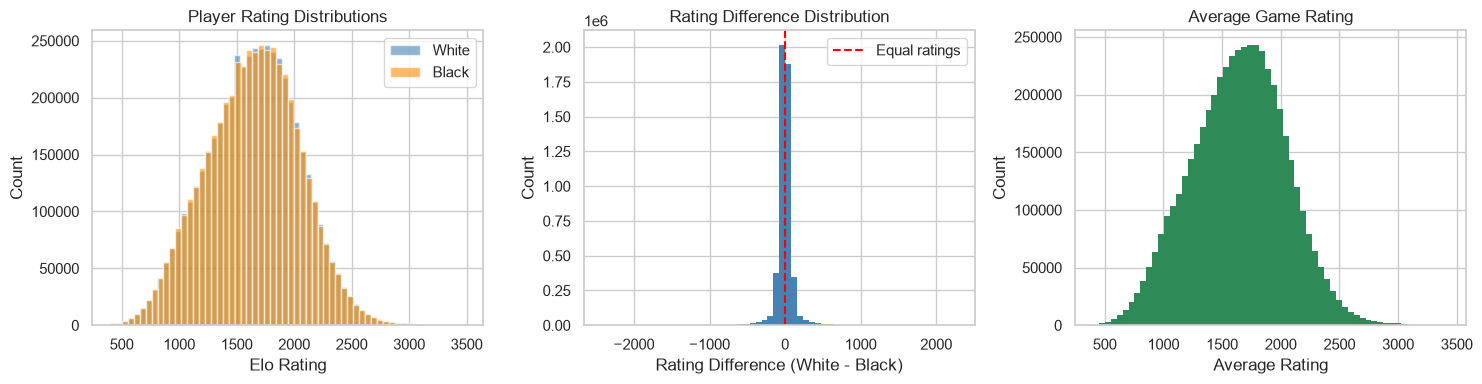

Rating bin counts and percentages:
  1000-1499     1,475,244  (29.6%)
  1500-1999     2,274,967  (45.7%)
  2000+          930,105  (18.7%)
  <1000          300,643  (6.0%)


In [21]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(df_feat['white_elo'], bins=60, alpha=0.6, label='White', color='steelblue')
axes[0].hist(df_feat['black_elo'], bins=60, alpha=0.6, label='Black', color='darkorange')
axes[0].set_xlabel('Elo Rating')
axes[0].set_ylabel('Count')
axes[0].set_title('Player Rating Distributions')
axes[0].legend()

axes[1].hist(df_feat['rating_diff'], bins=60, color='steelblue', edgecolor='none')
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.5, label='Equal ratings')
axes[1].set_xlabel('Rating Difference (White - Black)')
axes[1].set_ylabel('Count')
axes[1].set_title('Rating Difference Distribution')
axes[1].legend()

axes[2].hist(df_feat['avg_rating'], bins=60, color='seagreen', edgecolor='none')
axes[2].set_xlabel('Average Rating')
axes[2].set_ylabel('Count')
axes[2].set_title('Average Game Rating')

plt.tight_layout()
plt.show()

print('Rating bin counts and percentages:')
rb = df_feat['rating_bin'].value_counts().sort_index()
for bin_label, cnt in rb.items():
    print(f'  {bin_label:<12}  {cnt:>8,}  ({cnt / len(df_feat) * 100:.1f}%)')

### 4.3 Outcome Distributions

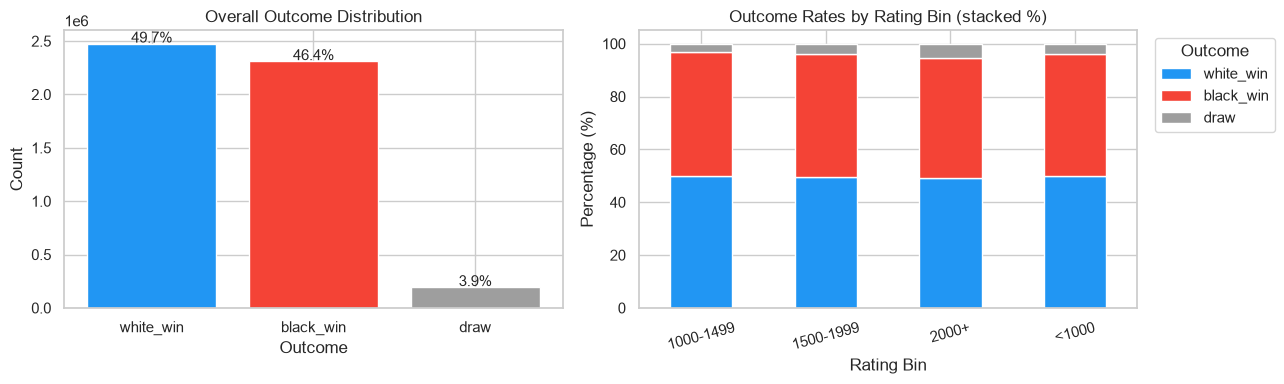

In [22]:
outcome_colors = {'white_win': '#2196F3', 'black_win': '#F44336', 'draw': '#9E9E9E'}
ordered_outcomes = ['white_win', 'black_win', 'draw']

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# ── Overall outcome bar ────────────────────────────────────────────────────
vc = df_feat['result_label'].value_counts().reindex(ordered_outcomes)
bars = axes[0].bar(
    vc.index,
    vc.values,
    color=[outcome_colors[o] for o in vc.index]
)
for bar, count in zip(bars, vc.values):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + len(df_feat) * 0.002,
        f'{count / len(df_feat) * 100:.1f}%',
        ha='center', fontsize=11
    )
axes[0].set_title('Overall Outcome Distribution')
axes[0].set_ylabel('Count')
axes[0].set_xlabel('Outcome')

# ── Outcome by rating bin (stacked %) ─────────────────────────────────────
ct = pd.crosstab(df_feat['rating_bin'], df_feat['result_label'], normalize='index') * 100
ct = ct.reindex(columns=ordered_outcomes)
ct.plot(kind='bar', stacked=True, ax=axes[1],
        color=[outcome_colors[o] for o in ordered_outcomes])
axes[1].set_title('Outcome Rates by Rating Bin (stacked %)')
axes[1].set_xlabel('Rating Bin')
axes[1].set_ylabel('Percentage (%)')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=15)
axes[1].legend(title='Outcome', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()

### 4.4 Chi-Squared Test: Rating Bin × Outcome

A chi-squared test on the contingency table of rating bin vs. outcome tests whether outcome distributions differ significantly across rating levels. A low p-value (conventionally < 0.05) suggests that rating level and outcome distribution are not independent.

In [23]:
ct_raw = pd.crosstab(df_feat['rating_bin'], df_feat['result_label'])
chi2, p, dof, expected = chi2_contingency(ct_raw)

print('Chi-squared test: Rating Bin x Outcome')
print(f'  chi2 = {chi2:.2f}   df = {dof}   p = {p:.4e}')
print()
print('Row-normalized contingency table (% within each rating bin):')
ct_pct = pd.crosstab(df_feat['rating_bin'], df_feat['result_label'], normalize='index') * 100
print(ct_pct.reindex(columns=ordered_outcomes).round(1).to_string())

Chi-squared test: Rating Bin x Outcome
  chi2 = 6351.97   df = 6   p = 0.0000e+00

Row-normalized contingency table (% within each rating bin):
result_label  white_win  black_win  draw
rating_bin                              
1000-1499          50.0       46.8   3.2
1500-1999          49.7       46.6   3.8
2000+              49.3       45.5   5.2
<1000              49.9       46.1   4.1


### 4.5 Time Control Analysis

Faster time controls (bullet) may favor White due to reduced thinking time, while slower controls (classical) tend to see more draws as both players have more opportunity to equalize.

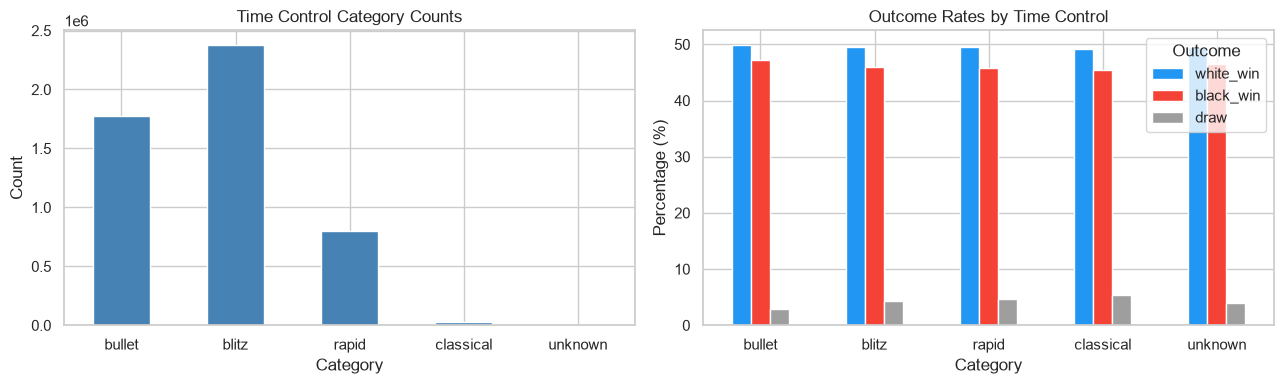

Chi-squared test: Time Control x Outcome
  chi2 = 8655.58   df = 8   p = 0.0000e+00


In [24]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# TC distribution
tc_order = ['bullet', 'blitz', 'rapid', 'classical', 'other', 'unknown']
tc_vc = df_feat['tc_cat'].value_counts().reindex(tc_order).dropna()
tc_vc.plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Time Control Category Counts')
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)

# Outcome by TC
ct_tc = pd.crosstab(df_feat['tc_cat'], df_feat['result_label'], normalize='index') * 100
ct_tc = ct_tc.reindex(index=tc_order, columns=ordered_outcomes).dropna(how='all')
ct_tc.plot(kind='bar', ax=axes[1],
           color=[outcome_colors[o] for o in ordered_outcomes])
axes[1].set_title('Outcome Rates by Time Control')
axes[1].set_xlabel('Category')
axes[1].set_ylabel('Percentage (%)')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
axes[1].legend(title='Outcome')

plt.tight_layout()
plt.show()

ct_tc_raw = pd.crosstab(df_feat['tc_cat'], df_feat['result_label'])
chi2_tc, p_tc, dof_tc, _ = chi2_contingency(ct_tc_raw)
print(f'Chi-squared test: Time Control x Outcome')
print(f'  chi2 = {chi2_tc:.2f}   df = {dof_tc}   p = {p_tc:.4e}')

### 4.6 Opening Move Analysis

White's first move (`ply_1`) and Black's response (`ply_2`) set the opening trajectory. The most common first moves (`e4`, `d4`, `Nf3`, `c4`) define broad opening families. We also test whether the first White move is associated with outcome using a chi-squared test.

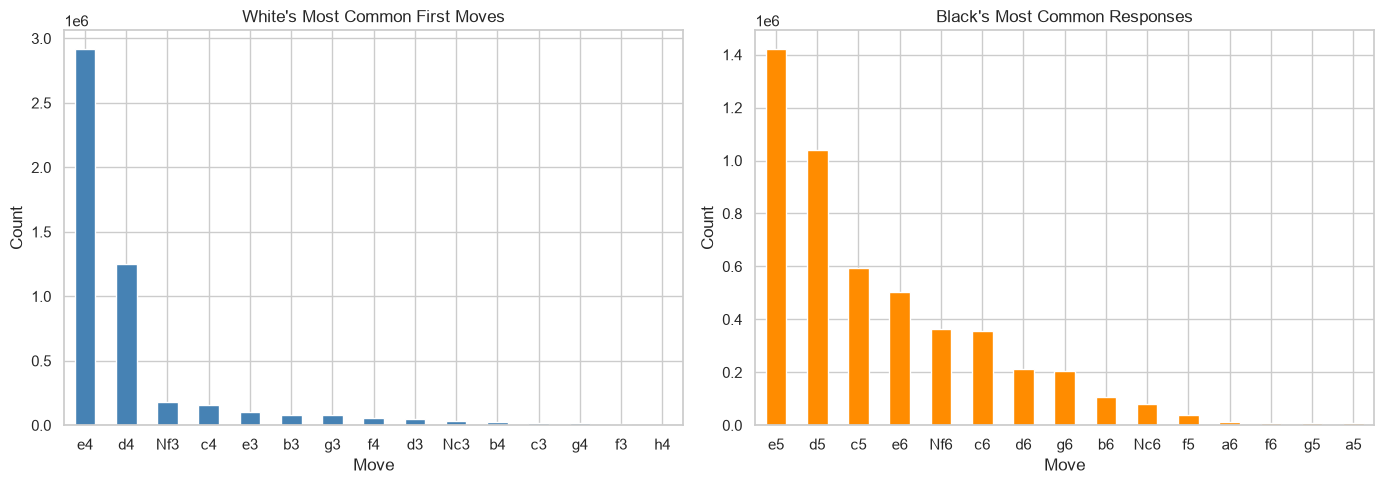

Outcome rates by White first move (top 10):
result_label  white_win  black_win  draw        n
ply_1                                            
Nc3                50.0       46.2   3.8    30583
Nf3                50.7       44.8   4.5   179896
b3                 50.3       46.0   3.7    81088
c4                 50.5       45.2   4.3   157348
d3                 48.6       47.8   3.6    47103
d4                 50.4       45.6   4.0  1247725
e3                 48.0       48.5   3.5   103059
e4                 49.4       46.8   3.8  2916023
f4                 50.0       46.5   3.5    55088
g3                 50.4       45.7   3.9    80957

Chi-squared test: White First Move x Outcome
  chi2 = 1292.30   df = 18   p = 1.8297e-263


In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

top_w1 = df_feat['ply_1'].value_counts().head(15)
top_b1 = df_feat['ply_2'].value_counts().head(15)

top_w1.plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title("White's Most Common First Moves")
axes[0].set_xlabel('Move')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)

top_b1.plot(kind='bar', ax=axes[1], color='darkorange')
axes[1].set_title("Black's Most Common Responses")
axes[1].set_xlabel('Move')
axes[1].set_ylabel('Count')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()

# Win rates for White's first move
print('Outcome rates by White first move (top 10):')
df_w1 = df_feat[df_feat['ply_1'].isin(top_w1.index[:10])]
w1_outcomes = pd.crosstab(df_w1['ply_1'], df_w1['result_label'], normalize='index') * 100
w1_outcomes = w1_outcomes.reindex(columns=ordered_outcomes)
w1_outcomes['n'] = df_w1.groupby('ply_1').size()
print(w1_outcomes.round(1).to_string())

ct_w1 = pd.crosstab(df_w1['ply_1'], df_w1['result_label'])
chi2_w1, p_w1, dof_w1, _ = chi2_contingency(ct_w1)
print(f'\nChi-squared test: White First Move x Outcome')
print(f'  chi2 = {chi2_w1:.2f}   df = {dof_w1}   p = {p_w1:.4e}')

### 4.7 Game Length Analysis

Game length (number of moves) varies substantially by outcome. Draws tend to be longer than decisive games, and games won by resignation may be shorter than games won by checkmate or time forfeit.

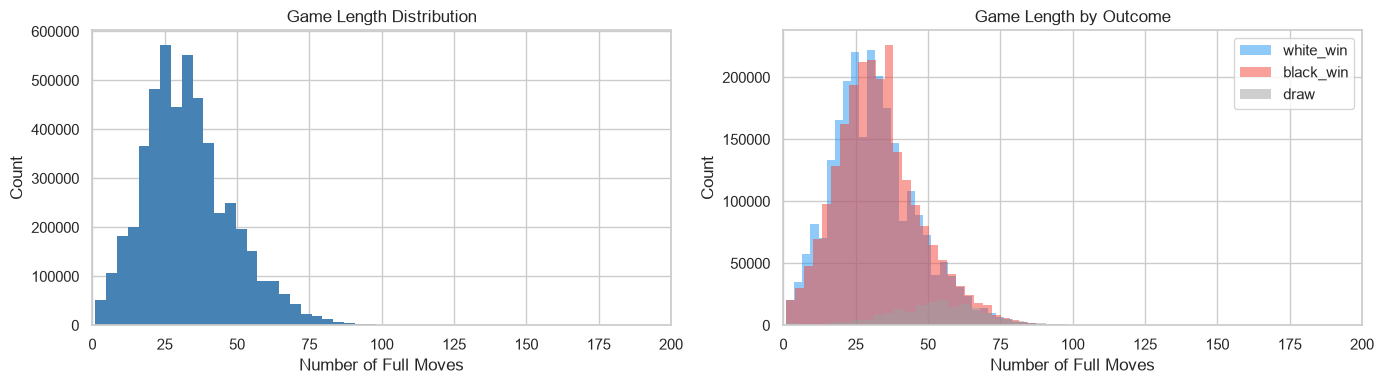

Game length summary statistics by outcome:
                    n  mean  median   std    Q1    Q3   IQR
result_label                                               
black_win     2311297  32.9    31.0  14.7  23.0  41.0  18.0
draw           194210  53.1    54.0  18.2  42.0  64.0  22.0
white_win     2475452  31.6    30.0  14.7  21.0  40.0  19.0


In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df_feat['num_moves'], bins=80, color='steelblue', edgecolor='none')
axes[0].set_xlabel('Number of Full Moves')
axes[0].set_ylabel('Count')
axes[0].set_title('Game Length Distribution')
axes[0].set_xlim(0, 200)

for outcome in ordered_outcomes:
    subset = df_feat[df_feat['result_label'] == outcome]['num_moves']
    axes[1].hist(subset, bins=80, alpha=0.5,
                 label=outcome, color=outcome_colors[outcome], edgecolor='none')
axes[1].set_xlabel('Number of Full Moves')
axes[1].set_ylabel('Count')
axes[1].set_title('Game Length by Outcome')
axes[1].set_xlim(0, 200)
axes[1].legend()

plt.tight_layout()
plt.show()

print('Game length summary statistics by outcome:')
gl_stats = df_feat.groupby('result_label')['num_moves'].agg(
    ['count', 'mean', 'median', 'std',
     lambda x: x.quantile(0.25),
     lambda x: x.quantile(0.75)]
)
gl_stats.columns = ['n', 'mean', 'median', 'std', 'Q1', 'Q3']
gl_stats['IQR'] = gl_stats['Q3'] - gl_stats['Q1']
print(gl_stats.round(1).to_string())

---
### Section 4 Recap

*To fill in after the full-dataset run:*
- Whether all three chi-squared tests (rating bin x outcome, time control x outcome, White's first move x outcome) keep the same significance pattern as the sample -- the first two were significant, the third was not (p=0.14), driven by small-sample noise in rare first moves. At full scale, rare first moves stop being small-sample, so this result could plausibly flip to significant even if the effect size stays tiny -- worth flagging explicitly if it does, since statistical significance at 84.6M rows is a much lower bar than practical significance.
- Game-length-by-outcome pattern -- confirm draws still run substantially longer than decisive games on average.
- Any newly-visible tail patterns (e.g. rare openings, rare time controls) that the 50K sample was too small to surface.

---
## Part II: Deep-Dive Analysis

Part I built `df_feat` with every field Part II needs, including the full per-game `moves` list -- no separate re-parse or file reload happens here. `TOP_N_PATTERNS` is defined below, where it's first used (Section 8); everything else Part II needs (`RAW_PGN`, `PARSE_MODE`, `N_RANDOM_SAMPLE`, `RANDOM_SEED`, the sklearn/numpy/pandas imports) already came from Part I's Section 0.

In [27]:
# Part II works from `df_deep`: the columns needed for full-game sequence
# mining, aliased directly from df_feat (already in memory from Part I) --
# no re-parse of the PGN and no reload from disk.
df_deep = df_feat[['game_id', 'moves', 'result_label', 'rating_bin', 'white_elo', 'black_elo']].copy()
print(f'Deep-analysis table: {len(df_deep):,} games')

Deep-analysis table: 4,980,959 games


In [28]:
# df_deep now holds its own copy of moves for Part II. df_feat's copy is
# never read again after this point (feat_lookup in Section 7 only pulls
# non-move columns) but nothing frees it otherwise -- at multi-million-game
# scale that's a second full, un-interned-on-disk-but-shared-in-memory copy
# of the moves column sitting alive for the rest of the notebook for no
# reason. Drop it explicitly.
df_feat.drop(columns=['moves'], inplace=True)
gc.collect()

26352

---
## Section 5: Contiguous Move-Sequence Patterns (n-grams)

Rather than tagging each move with its move number (which only matches a pattern if it shows up at that exact point in the game), this section works with the full game as one ordered, color-tagged sequence -- both players' moves interleaved in actual play order, each tagged with its side (`w-e4`, `b-e5`, `w-Nf3`, `b-Nc6`, ...) -- and mines **contiguous** runs of 6, 8, or 10 plies (roughly 3-5 full moves per side): no gaps, order preserved, free to occur *anywhere* in the game (there is no ply cap on how deep a pattern can be found). A pattern's strength is its lift: P(outcome | pattern present) / P(outcome overall), checked one-vs-rest against `white_win`, `black_win`, and `draw`.

`draw` needs its own, lower support floor: at a 3.7% base rate, the support of any (sequence ∩ draw) combination is capped well below what `white_win`/`black_win` (roughly 50%/46% base rate) allow, so the same floor that works for those two would leave almost no room for a draw-specific sequence to clear it.

An earlier pass also isolated each side's own moves in isolation (ignoring the opponent's replies), on the reasoning that a "White pattern" should reflect White's own choices. That version consistently found weaker, less chess-meaningful signal than the combined, interleaved version below (which found named, recognizable structures like the Two Knights Defense's sharp main line) -- since a move sequence that ignores what the opponent actually played is somewhat artificial for a fundamentally interactive game, this notebook now works only with the combined sequence.

In [29]:
from collections import defaultdict

def mine_contiguous_ngrams(sequences, wins, n, min_support=0.005):
    """Count contiguous n-move runs (order preserved, no gaps) and rank them
    by lift = P(win | pattern present) / P(win overall). A pattern is counted
    at most once per game (presence/absence, not raw count)."""
    n_games = len(sequences)
    base_rate = sum(wins) / n_games
    min_count = max(1, int(min_support * n_games))

    support_count = defaultdict(int)
    win_count = defaultdict(int)
    for moves, won in zip(sequences, wins):
        seen = {tuple(moves[i:i + n]) for i in range(len(moves) - n + 1)}
        for gram in seen:
            support_count[gram] += 1
            if won:
                win_count[gram] += 1

    rows = []
    for gram, count in support_count.items():
        if count < min_count:
            continue
        confidence = win_count[gram] / count
        rows.append({
            'sequence': ' '.join(gram),
            'n': n,
            'support': count / n_games,
            'confidence': confidence,
            'lift': confidence / base_rate,
        })

    cols = ['sequence', 'n', 'support', 'confidence', 'lift']
    if not rows:
        return pd.DataFrame(columns=cols)
    return pd.DataFrame(rows).sort_values('lift', ascending=False).reset_index(drop=True)

In [30]:
def build_full_game_sequences(df, outcome_col='result_label'):
    """One tagged sequence per game covering the ENTIRE game -- both colors'
    moves in actual play order, each tagged with its color (e.g. 'w-e4', 'b-e5',
    'w-Nf3', ...) -- plus white_win/black_win/draw flags. No ply cap: the full
    move list already parsed into df['moves'] is used as-is, so a pattern can
    be found anywhere in the game, not just in an early window.

    Tagged strings are interned (sys.intern): the vocabulary of possible
    tagged moves is small (a few thousand distinct values at most), but
    without interning, every ply of every game would allocate its own fresh
    string object even though millions of games share the same opening moves.
    Measured on the 50K-game sample: interning cuts this structure's memory
    from ~3,776 to ~725 bytes/game -- at full scale (84.6M games) that's the
    difference between an estimated ~320GB and ~61GB for this one object.
    """
    sequences, white_wins, black_wins, draws = [], [], [], []
    for _, row in df.iterrows():
        moves = row['moves']
        tagged = [sys.intern(f"{'w' if i % 2 == 0 else 'b'}-{mv}") for i, mv in enumerate(moves)]
        sequences.append(tagged)
        outcome = row.get(outcome_col)
        white_wins.append(int(pd.notna(outcome) and outcome == 'white_win'))
        black_wins.append(int(pd.notna(outcome) and outcome == 'black_win'))
        draws.append(int(pd.notna(outcome) and outcome == 'draw'))
    return sequences, white_wins, black_wins, draws


combined_seqs, combined_white_wins, combined_black_wins, combined_draws = build_full_game_sequences(df_deep)

print(f'Combined sequences: {len(combined_seqs):,}')
print(f'white_win rate: {np.mean(combined_white_wins):.3f}   black_win rate: {np.mean(combined_black_wins):.3f}   draw rate: {np.mean(combined_draws):.3f}')
print(f'Sample (first 10 plies): {combined_seqs[0][:10]}')

Combined sequences: 4,980,959
white_win rate: 0.497   black_win rate: 0.464   draw rate: 0.039
Sample (first 10 plies): ['w-g3', 'b-g6', 'w-d3', 'b-Bg7', 'w-Bg2', 'b-d6', 'w-c3', 'b-e5', 'w-Qb3', 'b-Nc6']


In [31]:
MIN_SUPPORT_COMBINED = 0.002  # long, color-tagged, exact-order runs are rare,
                                # so the support floor is lower than a shorter/unordered pattern would need
MIN_SUPPORT_DRAW = 0.0025      # lower base rate (3.7%) needs its own floor, same logic as white/black
NGRAM_LENGTHS_COMBINED = [6, 8, 10]

combined_white_rules = pd.concat(
    [mine_contiguous_ngrams(combined_seqs, combined_white_wins, n, MIN_SUPPORT_COMBINED) for n in NGRAM_LENGTHS_COMBINED],
    ignore_index=True
).sort_values('lift', ascending=False).reset_index(drop=True)

print(f'Combined -> white_win: {len(combined_white_rules):,} sequences at support >= {MIN_SUPPORT_COMBINED:.1%}')
combined_white_rules.head(15)

Combined -> white_win: 83 sequences at support >= 0.2%


,sequence,n,support,confidence,lift
0,w-e4 b-e5 w-d4 b-exd4 w-c3 b-dxc3,6,0.002012,0.558826,1.124438
1,b-Nc6 w-d4 b-exd4 w-Nxd4 b-Nxd4 w-Qxd4,6,0.003995,0.541156,1.088882
2,b-e5 w-Nf3 b-Nc6 w-d4 b-exd4 w-Nxd4 b-Nxd4 w-Qxd4,8,0.003541,0.540620,1.087804
3,w-e4 b-e5 w-Nf3 b-Nc6 w-d4 b-exd4 w-Nxd4 b-Nxd4,8,0.003504,0.539105,1.084755
4,w-Nf3 b-Nc6 w-d4 b-exd4 w-Nxd4 b-Nxd4,6,0.003699,0.538695,1.083931
5,b-e5 w-Nf3 b-Nc6 w-d4 b-exd4 w-Bc4,6,0.002933,0.531622,1.069699
6,b-e5 w-Nf3 b-Nc6 w-Bc4 b-Nf6 w-Ng5,6,0.003657,0.525637,1.057655
7,w-e4 b-e5 w-Nf3 b-Nc6 w-d4 b-exd4,6,0.013378,0.520980,1.048286
8,w-e4 b-e5 w-Nf3 b-Nf6 w-Nc3 b-Nc6,6,0.002214,0.520860,1.048043
9,w-d4 b-d5 w-c4 b-e6 w-Nc3 b-Nf6,6,0.003098,0.516946,1.040169


In [32]:
combined_black_rules = pd.concat(
    [mine_contiguous_ngrams(combined_seqs, combined_black_wins, n, MIN_SUPPORT_COMBINED) for n in NGRAM_LENGTHS_COMBINED],
    ignore_index=True
).sort_values('lift', ascending=False).reset_index(drop=True)

print(f'Combined -> black_win: {len(combined_black_rules):,} sequences at support >= {MIN_SUPPORT_COMBINED:.1%}')
combined_black_rules.head(15)

Combined -> black_win: 83 sequences at support >= 0.2%


,sequence,n,support,confidence,lift
0,w-e4 b-c6 w-Bc4 b-d5 w-exd5 b-cxd5,6,0.002848,0.530660,1.143598
1,b-c6 w-Bc4 b-d5 w-exd5 b-cxd5 w-Bb3,6,0.002045,0.519980,1.120583
2,w-e4 b-e6 w-d4 b-d5 w-e5 b-c5,6,0.005146,0.504994,1.088287
3,w-d4 b-d5 w-e5 b-c5 w-c3 b-Nc6,6,0.003226,0.501089,1.079872
4,w-e4 b-d5 w-exd5 b-Nf6 w-Nc3 b-Nxd5,6,0.002610,0.499769,1.077027
5,w-e4 b-c6 w-Nf3 b-d5 w-exd5 b-cxd5,6,0.008207,0.498324,1.073914
6,b-d5 w-e5 b-c5 w-c3 b-Nc6 w-Nf3,6,0.002372,0.497926,1.073055
7,w-e4 b-c6 w-Nf3 b-d5 w-exd5 b-cxd5 w-d4 b-Nc6,8,0.002314,0.497917,1.073037
8,w-Nf3 b-d5 w-exd5 b-cxd5 w-d4 b-Nc6,6,0.002328,0.497715,1.072599
9,w-e4 b-e6 w-d4 b-d5 w-e5 b-c5 w-c3 b-Nc6,8,0.002356,0.496379,1.069721


In [33]:
combined_draw_rules = pd.concat(
    [mine_contiguous_ngrams(combined_seqs, combined_draws, n, MIN_SUPPORT_DRAW) for n in NGRAM_LENGTHS_COMBINED],
    ignore_index=True
).sort_values('lift', ascending=False).reset_index(drop=True)

print(f'Combined -> draw: {len(combined_draw_rules):,} sequences at support >= {MIN_SUPPORT_DRAW:.2%}')
combined_draw_rules.head(15)

Combined -> draw: 59 sequences at support >= 0.25%


,sequence,n,support,confidence,lift
0,w-e4 b-e5 w-Nf3 b-Nc6 w-Bb5 b-Nf6,6,0.003636,0.080678,2.069175
1,b-e5 w-Nf3 b-Nc6 w-Bb5 b-a6 w-Ba4,6,0.002512,0.054836,1.406398
2,b-c5 w-Nf3 b-d6 w-d4 b-cxd4 w-Nxd4 b-Nf6 w-Nc3,8,0.003682,0.052075,1.335578
3,w-e4 b-e5 w-Nf3 b-Nc6 w-Bb5 b-a6,6,0.004199,0.051929,1.331849
4,b-d6 w-d4 b-cxd4 w-Nxd4 b-Nf6 w-Nc3,6,0.003716,0.051921,1.331625
5,w-e4 b-c5 w-Nf3 b-d6 w-d4 b-cxd4 w-Nxd4 b-Nf6,8,0.004219,0.051339,1.316716
6,w-Nf3 b-d6 w-d4 b-cxd4 w-Nxd4 b-Nf6,6,0.004296,0.051178,1.312571
7,w-e4 b-e6 w-d4 b-d5 w-exd5 b-exd5,6,0.005263,0.049554,1.270917
8,w-e4 b-c6 w-d4 b-d5 w-exd5 b-cxd5,6,0.005939,0.048783,1.25115
9,b-c5 w-Nf3 b-d6 w-d4 b-cxd4 w-Nxd4,6,0.005665,0.048409,1.241555


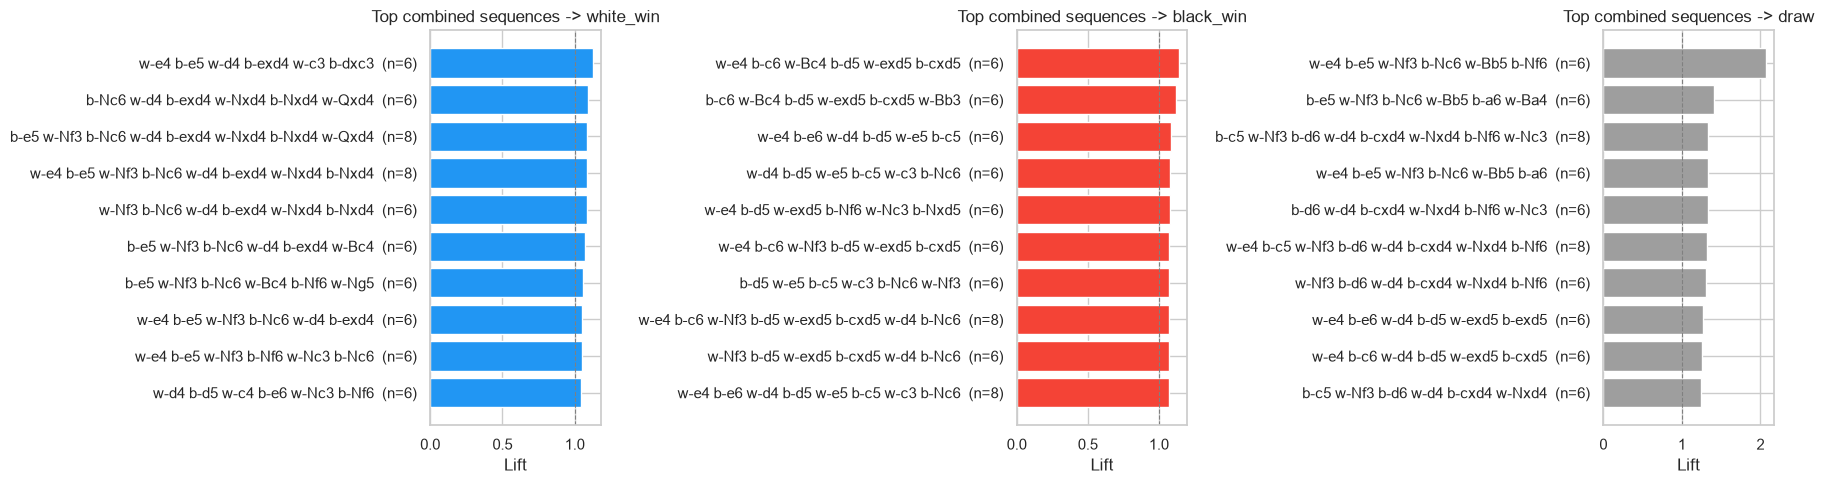

In [34]:
# Side-by-side comparison of the strongest combined interleaved sequences, per outcome
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, rules, color, title in [
    (axes[0], combined_white_rules, '#2196F3', 'Top combined sequences -> white_win'),
    (axes[1], combined_black_rules, '#F44336', 'Top combined sequences -> black_win'),
    (axes[2], combined_draw_rules, '#9E9E9E', 'Top combined sequences -> draw'),
]:
    top = rules.head(10).copy()
    top['label'] = top['sequence'] + '  (n=' + top['n'].astype(str) + ')'
    top = top.iloc[::-1]
    ax.barh(top['label'], top['lift'], color=color)
    ax.set_xlabel('Lift')
    ax.set_title(title)
    ax.axvline(1.0, color='gray', linestyle='--', linewidth=0.8)

plt.tight_layout()
plt.show()

### Section 5 Recap

*To fill in after the full-dataset run:*
- Number of sequences clearing the support floor for each outcome (`white_win`/`black_win`/`draw`) at full scale -- with ~1700x more games, expect far more sequences to clear a fixed percentage-based support floor; consider whether `MIN_SUPPORT_COMBINED`/`MIN_SUPPORT_DRAW` need raising to keep the result sets interpretable.
- Top-lift sequence per outcome -- compare to the sample's `e4 c5 Nf3 Nc6 Bc4 e6` (white_win, 1.173), the Two Knights line (black_win, 1.246), and the Advance Caro-Kann (draw, 1.922). Do the same sequences remain on top, or does more data surface different (likely more statistically stable) leaders?
- Whether lift values compress toward 1.0 with more data (a common pattern as sample noise shrinks) or hold steady.

---
## Section 6: Do Combined-Sequence Patterns Hold Up Across Rating Levels?

The proposal's motivating question was explicit: *"a move sequence may appear strong overall but may only be successful at certain rating levels."* This repeats Section 5's method -- contiguous 6/8/10-ply runs of the combined, color-tagged game sequence, checked against `white_win` and `black_win` -- separately within each `rating_bin`, so the same overall pattern can be checked for whether its lift holds, strengthens, or disappears as player strength changes.

Bin sizes are uneven (`rating_bin` is bell-shaped, centered on `1500-1999`), so `MIN_SUPPORT_BIN_NGRAM` is set a little higher than Section 5's 0.2% floor to keep exact-order runs from becoming so rare in the smaller bins (`<1000`, `2000+`) that they're just noise.

In [35]:
RATING_BINS = ['<1000', '1000-1499', '1500-1999', '2000+']
MIN_SUPPORT_BIN_NGRAM = 0.005
NGRAM_LENGTHS_BIN = [6, 8, 10]

bin_rules = {}
for rb in RATING_BINS:
    df_bin = df_deep[df_deep['rating_bin'] == rb]
    if len(df_bin) < 200:
        print(f'{rb}: only {len(df_bin)} games -- skipping (too few transactions for stable n-grams)')
        continue

    bin_seqs, bin_white_wins, bin_black_wins, _ = build_full_game_sequences(df_bin)  # draws unused here

    w_rules = pd.concat(
        [mine_contiguous_ngrams(bin_seqs, bin_white_wins, n, MIN_SUPPORT_BIN_NGRAM) for n in NGRAM_LENGTHS_BIN],
        ignore_index=True
    ).sort_values('lift', ascending=False).reset_index(drop=True)
    b_rules = pd.concat(
        [mine_contiguous_ngrams(bin_seqs, bin_black_wins, n, MIN_SUPPORT_BIN_NGRAM) for n in NGRAM_LENGTHS_BIN],
        ignore_index=True
    ).sort_values('lift', ascending=False).reset_index(drop=True)

    print(f'{rb}: {len(df_bin):,} games | ->white_win sequences: {len(w_rules):,} | ->black_win sequences: {len(b_rules):,}')
    bin_rules[rb] = {'n_games': len(df_bin), 'white': w_rules, 'black': b_rules}

<1000: 300,643 games | ->white_win sequences: 13 | ->black_win sequences: 13
1000-1499: 1,475,244 games | ->white_win sequences: 20 | ->black_win sequences: 20
1500-1999: 2,274,967 games | ->white_win sequences: 17 | ->black_win sequences: 17
2000+: 930,105 games | ->white_win sequences: 28 | ->black_win sequences: 28


In [36]:
# Top 3 sequences per rating bin, for each outcome, side by side
rows = []
for rb in RATING_BINS:
    if rb not in bin_rules:
        continue
    for outcome, rules in [('white_win', bin_rules[rb]['white']), ('black_win', bin_rules[rb]['black'])]:
        for _, r in rules.head(3).iterrows():
            rows.append({
                'rating_bin': rb, 'outcome': outcome, 'pattern': r['sequence'], 'n': r['n'],
                'support': r['support'], 'confidence': r['confidence'], 'lift': r['lift'],
            })

bin_summary = pd.DataFrame(rows)
bin_summary

,rating_bin,outcome,pattern,n,support,confidence,lift
0,<1000,white_win,w-e4 b-e5 w-Nf3 b-Nf6 w-Nxe5 b-Nxe4,6,0.005222,0.600000,1.203198
1,<1000,white_win,b-e5 w-Nf3 b-Nc6 w-Bc4 b-Nf6 w-Ng5,6,0.006230,0.584090,1.171292
2,<1000,white_win,w-e4 b-e5 w-Nf3 b-Nf6 w-Nc3 b-Nc6,6,0.005309,0.572055,1.147159
3,<1000,black_win,w-e4 b-e5 w-Qh5 b-Nf6 w-Qxe5+ b-Be7,6,0.005309,0.521303,1.132022
4,<1000,black_win,w-e4 b-e5 w-Qh5 b-Nc6 w-Bc4 b-g6,6,0.005671,0.516129,1.120786
5,<1000,black_win,w-e4 b-e5 w-Nf3 b-Nc6 w-Nc3 b-Bc5,6,0.005681,0.497073,1.079405
6,1000-1499,white_win,b-e5 w-Nf3 b-Nc6 w-d4 b-exd4 w-Nxd4 b-Nxd4 w-Qxd4,8,0.005910,0.541232,1.083183
7,1000-1499,white_win,w-e4 b-e5 w-Nf3 b-Nc6 w-d4 b-exd4 w-Nxd4 b-Nxd4,8,0.005869,0.539617,1.079950
8,1000-1499,white_win,b-Nc6 w-d4 b-exd4 w-Nxd4 b-Nxd4 w-Qxd4,6,0.006567,0.538501,1.077718
9,1000-1499,black_win,w-e4 b-c6 w-Nf3 b-d5 w-exd5 b-cxd5,6,0.008375,0.512424,1.094982


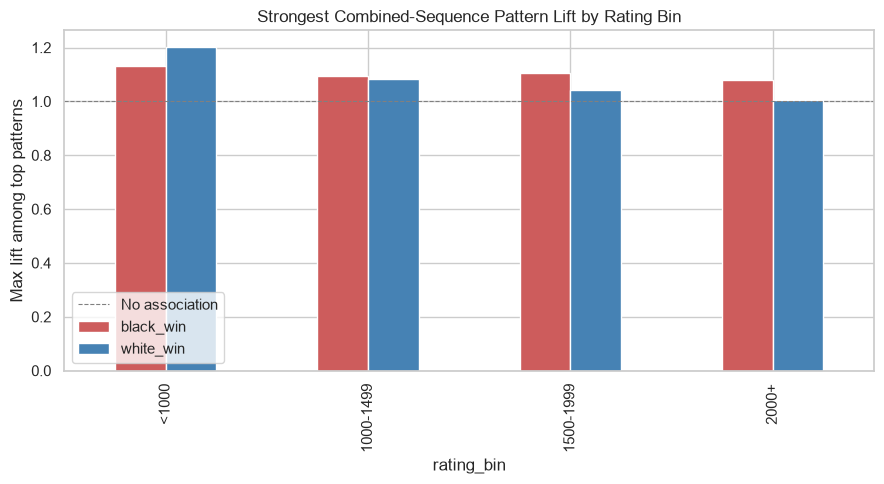

In [37]:
# Visual comparison: strongest lift found per rating bin, by outcome
best_by_bin = (
    bin_summary.groupby(['rating_bin', 'outcome'])['lift'].max().unstack()
    .reindex(RATING_BINS)
)

fig, ax = plt.subplots(figsize=(9, 5))
best_by_bin.plot(kind='bar', ax=ax, color=['indianred', 'steelblue'])
ax.axhline(1.0, color='gray', linestyle='--', linewidth=0.8, label='No association')
ax.set_ylabel('Max lift among top patterns')
ax.set_title('Strongest Combined-Sequence Pattern Lift by Rating Bin')
ax.legend()
plt.tight_layout()
plt.show()

### Section 6 Recap

*To fill in after the full-dataset run:*
- Sequences-per-bin counts at full scale -- the sample ranged from 11 (`<1000`) to 26 (`2000+`) per outcome; full-scale bin sizes will be ~1700x larger, so expect substantially more sequences per bin and correspondingly more stable lift estimates.
- Strongest sequence per bin, and whether the pattern of White's edge shrinking with rating (sample: `<1000` lift 1.329 down to a near-even split at `2000+`) holds up.
- Whether any single sequence now tops more than one bin's list (none did in the sample) -- would suggest a genuinely rating-independent effect rather than noise.

---
## Section 7: Predictive Modeling I — Features Known Before the Game Starts

This is the first of the two models the progress report calls for: *"one model that predicts game outcome based on features known prior to start of game."* Only information that exists before a single move is played is eligible.

**Restructured to one row per *player*, not per game.** The previous version predicted `white_wins` directly, with `rating_diff = white_elo - black_elo` signed around White -- which meant any advantage from simply *being* White was invisible, silently absorbed into the model's intercept rather than estimated as its own effect. Here, each game contributes two mirrored rows: one from White's perspective (`own_rating_diff = white_elo - black_elo`, `color = white`, target = did White win) and one from Black's (`own_rating_diff = black_elo - white_elo`, `color = black`, target = did Black win). That makes `color` a real, estimable feature -- separate from rating -- rather than something baked into the target's definition.

Features used:
- `own_rating_diff`, `avg_rating` — both players' Elo ratings are known before the game starts
- `tc_cat` — the time control is selected before the game starts
- `color` — which side a player is assigned is known before the first move

Everything else the pipeline notebook used as a feature (`num_plies`, `eco_family`, `opening_family`, `ply_1`) is determined *during or after* play and is excluded here — including `num_plies`, which the pipeline notebook's preliminary model used despite it only being knowable once the game is already over.

Two models are compared against the same two baselines the pipeline notebook used (majority class, and the zero-training "higher-rated player wins" heuristic): Random Forest, per the progress report's modeling decision, and Logistic Regression -- added because Elo ratings are *defined* so that expected score is a logistic function of rating difference, making it the theoretically motivated model to check Random Forest's added flexibility against.

**One structural detail that matters:** since each game now produces two rows, the train/test split is done on `game_id` *first*, then expanded to player-rows -- otherwise a game's two mirrored perspectives could end up split across train and test, leaking information about a test game into training.

In [38]:
PRE_GAME_NUM = ['own_rating_diff', 'avg_rating']
PRE_GAME_CAT = ['tc_cat', 'color']
PRE_GAME_FEATURES = PRE_GAME_NUM + PRE_GAME_CAT

TARGET_BIN   = 'own_win'
TARGET_MULTI = 'own_result'

def to_own_result(result_label, color):
    win_label = f'{color}_win'
    return np.where(result_label == 'draw', 'draw', np.where(result_label == win_label, 'win', 'loss'))

white_rows = pd.DataFrame({
    'game_id':         df_feat['game_id'],
    'color':           'white',
    'own_rating_diff': df_feat['white_elo'] - df_feat['black_elo'],
    'avg_rating':      df_feat['avg_rating'],
    'tc_cat':          df_feat['tc_cat'],
    'own_win':         df_feat['white_wins'],
    'own_result':      to_own_result(df_feat['result_label'].values, 'white'),
})
black_rows = pd.DataFrame({
    'game_id':         df_feat['game_id'],
    'color':           'black',
    'own_rating_diff': df_feat['black_elo'] - df_feat['white_elo'],
    'avg_rating':      df_feat['avg_rating'],
    'tc_cat':          df_feat['tc_cat'],
    'own_win':         (df_feat['result_label'] == 'black_win').astype(int),
    'own_result':      to_own_result(df_feat['result_label'].values, 'black'),
})

df_players = pd.concat([white_rows, black_rows], ignore_index=True)
df_players[PRE_GAME_CAT] = df_players[PRE_GAME_CAT].fillna('missing')
df_players = df_players.dropna(subset=PRE_GAME_NUM)

print(f'Player-perspective rows: {len(df_players):,}  ({len(df_feat):,} games x 2 perspectives)')
print(f'Pre-game features: {PRE_GAME_FEATURES}')

Player-perspective rows: 9,961,918  (4,980,959 games x 2 perspectives)
Pre-game features: ['own_rating_diff', 'avg_rating', 'tc_cat', 'color']


In [39]:
# Split by game_id first, then expand to player-rows -- a game's two mirrored
# rows must never end up split across train and test
train_game_ids, test_game_ids = train_test_split(
    df_feat['game_id'], test_size=0.2, random_state=RANDOM_SEED, stratify=df_feat['result_label']
)
train_mask = df_players['game_id'].isin(set(train_game_ids))
test_mask  = df_players['game_id'].isin(set(test_game_ids))

X_train, X_test   = df_players.loc[train_mask, PRE_GAME_FEATURES], df_players.loc[test_mask, PRE_GAME_FEATURES]
yb_train, yb_test = df_players.loc[train_mask, TARGET_BIN].astype(int), df_players.loc[test_mask, TARGET_BIN].astype(int)
ym_train, ym_test = df_players.loc[train_mask, TARGET_MULTI], df_players.loc[test_mask, TARGET_MULTI]

pre_game_preprocessor = ColumnTransformer([
    ('num', StandardScaler(), PRE_GAME_NUM),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), PRE_GAME_CAT),
], remainder='drop')

X_train_pg = pre_game_preprocessor.fit_transform(X_train)
X_test_pg  = pre_game_preprocessor.transform(X_test)

print(f'Train: {len(X_train):,} player-rows from {len(train_game_ids):,} games')
print(f'Test:  {len(X_test):,} player-rows from {len(test_game_ids):,} games')
print(f'Encoded feature matrix: {X_train_pg.shape}')

Train: 7,969,534 player-rows from 3,984,767 games
Test:  1,992,384 player-rows from 996,192 games
Encoded feature matrix: (7969534, 9)


In [40]:
def evaluate_binary(name, y_true, y_pred, y_prob_pos=None):
    return {
        'Model':     name,
        'Accuracy':  accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall':    recall_score(y_true, y_pred, zero_division=0),
        'F1':        f1_score(y_true, y_pred, zero_division=0),
        'ROC-AUC':   roc_auc_score(y_true, y_prob_pos) if y_prob_pos is not None else np.nan,
    }

model_a_results = []

# -- Baselines ------------------------------------------------------------------
dummy = DummyClassifier(strategy='most_frequent', random_state=RANDOM_SEED)
dummy.fit(X_train_pg, yb_train)
model_a_results.append(evaluate_binary(
    'Majority Class', yb_test, dummy.predict(X_test_pg), dummy.predict_proba(X_test_pg)[:, 1]
))

own_rating_diff_test = X_test['own_rating_diff'].values
yb_pred_hr = (own_rating_diff_test > 0).astype(int)
model_a_results.append(evaluate_binary('Higher-Rated Wins', yb_test, yb_pred_hr))

# -- Logistic Regression -- Elo's win probability is defined as a logistic
# function of rating difference, so this is the theoretically motivated model
# to check Random Forest's added flexibility against ---------------------------
logreg_a = LogisticRegression(max_iter=1000, random_state=RANDOM_SEED)
logreg_a.fit(X_train_pg, yb_train)
yb_pred_lr = logreg_a.predict(X_test_pg)
yb_prob_lr = logreg_a.predict_proba(X_test_pg)[:, 1]
model_a_results.append(evaluate_binary('Logistic Regression (pre-game)', yb_test, yb_pred_lr, yb_prob_lr))

# -- Random Forest (the report's chosen model) -----------------------------------
rf_a = RandomForestClassifier(
    n_estimators=200, max_depth=12, min_samples_leaf=30,
    random_state=RANDOM_SEED, n_jobs=-1
)
rf_a.fit(X_train_pg, yb_train)
yb_pred_a = rf_a.predict(X_test_pg)
yb_prob_a = rf_a.predict_proba(X_test_pg)[:, 1]
model_a_results.append(evaluate_binary('Random Forest (pre-game)', yb_test, yb_pred_a, yb_prob_a))

results_a_df = pd.DataFrame(model_a_results).set_index('Model')
print('Model A -- pre-game features only (target: own_win)')
print(results_a_df.round(4).to_string())

Model A -- pre-game features only (target: own_win)
                                Accuracy  Precision  Recall      F1  ROC-AUC
Model                                                                       
Majority Class                    0.5195     0.0000  0.0000  0.0000   0.5000
Higher-Rated Wins                 0.5529     0.5339  0.5478  0.5407      NaN
Logistic Regression (pre-game)    0.5586     0.5580  0.3911  0.4599   0.5867
Random Forest (pre-game)          0.5588     0.5560  0.4060  0.4693   0.5872


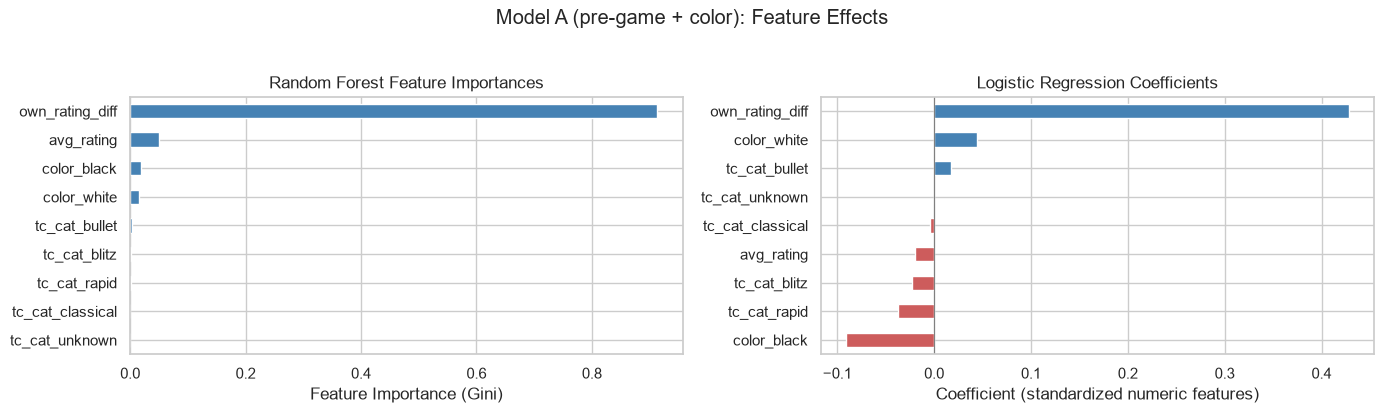

own_rating_diff     0.912216
avg_rating          0.049935
color_black         0.017886
color_white         0.014941
tc_cat_bullet       0.002619
tc_cat_blitz        0.001134
tc_cat_rapid        0.000764
tc_cat_classical    0.000314
tc_cat_unknown      0.000191
dtype: float64

In [41]:
# RF feature importance and LogReg coefficients side by side -- the coefficient
# panel directly shows the sign and size of the color (White vs. Black) effect,
# which Gini importance alone can't (it shows magnitude, not direction)
cat_names_a = pre_game_preprocessor.named_transformers_['cat'].get_feature_names_out(PRE_GAME_CAT).tolist()
feature_names_a = PRE_GAME_NUM + cat_names_a

feat_imp_a = pd.Series(rf_a.feature_importances_, index=feature_names_a).sort_values(ascending=False)
coef_a = pd.Series(logreg_a.coef_[0], index=feature_names_a).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

feat_imp_a.plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].invert_yaxis()
axes[0].set_xlabel('Feature Importance (Gini)')
axes[0].set_title('Random Forest Feature Importances')

bar_colors = ['indianred' if v < 0 else 'steelblue' for v in coef_a.values]
coef_a.plot(kind='barh', ax=axes[1], color=bar_colors)
axes[1].axvline(0, color='gray', linewidth=0.8)
axes[1].set_xlabel('Coefficient (standardized numeric features)')
axes[1].set_title('Logistic Regression Coefficients')

plt.suptitle('Model A (pre-game + color): Feature Effects', y=1.03)
plt.tight_layout()
plt.show()

feat_imp_a

### Section 7 Recap

*To fill in after the full-dataset run:*
- Model A accuracy/F1/ROC-AUC at full scale, compared to the sample (Logistic Regression 55.7% / F1 0.465 / AUC 0.589; Random Forest 55.6% / F1 0.477 / AUC 0.584) and to the zero-training higher-rated-wins heuristic (55.6%). With ~1700x more data, expect tighter confidence around these numbers even if the point estimates barely move.
- `color_white`/`color_black` Logistic Regression coefficients -- confirm the White edge (sample: +0.048 / -0.094, a ~0.14 log-odds swing) holds at full scale, and whether it's now estimated precisely enough to say more about its size relative to `own_rating_diff` (sample coefficient 0.416).
- RF feature importance split between `own_rating_diff` and `avg_rating` -- note whether the full run's ratio (sample: 70.2% / 25.9%) is stable.

---
## Section 8: Predictive Modeling II — Pattern Timing Across the Game

The second model the progress report calls for: one that *"predicts the outcome of the game at k-move intervals based on whether or not any frequent patterns have been detected in those k-moves."* This version replaces the earlier single fixed checkpoint (`K_EARLY`) with a much richer setup, built around the same four conceptual steps throughout this notebook's development:

1. **Deduplicate Section 5's mined sequences.** Many of the n=6/8/10 rules are just nested extensions of the same core idea (identical lift, one contained in the other) -- collapse those to the longest version only. Separately, a sequence and its exact color-flip (`w-`/`b-` tags swapped) can independently rank highly under two different outcomes -- collapse those to whichever has the higher lift.
2. **Find where each surviving top-20-per-outcome pattern (60 total) first occurs** in every game it appears in, plus that game's total ply count.
3. **Build a checkpoint panel**: every game contributes one row per checkpoint at ply 10, 20, 30, ... up through the last multiple of 10 *strictly before* that game ends (so a 47-ply game gets checkpoints at 10/20/30/40; games of 10 plies or fewer contribute none). Each checkpoint row gets one binary flag per pattern: has it begun by this checkpoint, yes or no.
4. **Expand to per-player rows** the same way Section 7 does (`color`, `own_rating_diff`, `own_win`), and fit **one model** across the whole panel with `checkpoint_ply` itself as a feature -- rather than a separate model per checkpoint, which would leave the later, rarer checkpoints starved of training data.

**Initial approach (what actually ran on the 50K-game sample).** Steps 2-4 were first implemented the straightforward way: a nested loop checking each of the 60 patterns against every game in turn (Step 2), and a single dense DataFrame holding one row per (game, checkpoint, player) with all 60 pattern-flag columns materialized at once (Steps 3-4), which is what got handed to `ColumnTransformer` and `RandomForestClassifier.fit()` directly. At 50K games that's ~614K rows -- fast and unremarkable.

**Why it had to change.** Extrapolated to the full 84.6M-game dataset, the same construction becomes:
- **Step 2**: ~5 billion pattern-game checks (60 patterns × 84.6M games) in a Python-level nested loop.
- **Steps 3-4**: an estimated **~1.04 billion rows** once every 10-ply checkpoint is expanded across every game and mirrored for both players -- roughly 150-300+ GB once that table is one-hot encoded and passed into a model fit, extrapolating directly from the sample run's measured per-row memory footprint.

That second number isn't a "this will be slow" problem, it's a "this will not fit in memory on any realistically priced machine" problem -- and a bigger cloud instance doesn't fix it, because the row count comes directly from the exhaustive, every-10-ply, every-game, both-players design that's the entire point of this section. Subsampling games or checkpoints would fix the memory problem but quietly change what's being measured. The fix instead had to touch every game, every checkpoint, and both players -- just never hold the whole panel as one object at once.

**Redesigned approach (what's implemented below):**
1. **Occurrence detection is a single pass per game across all 60 patterns at once**, using an Aho-Corasick automaton built once from the pattern set, instead of one pass per pattern per game. Verified to return byte-for-byte identical results to the original nested-loop method (9,135/9,135 occurrences matched exactly on the sample).
2. **The checkpoint panel is never fully materialized.** Games are processed in bounded-size chunks. Each chunk's (game, checkpoint, player) rows are built the same way as before, but:
   - **Training rows** are kept via checkpoint-stratified reservoir sampling -- a bounded number of rows per exact `checkpoint_ply` value, drawn as an unbiased random sample using keep-probabilities computed up front from an exact count of how many training rows exist at each checkpoint (a cheap single pass over game lengths and train/test membership, no player-row expansion needed just for that count).
   - **Test rows** are scored by the fitted model immediately, chunk by chunk, keeping only the compact result (`checkpoint_ply`, true label, predicted probability) and discarding the wide feature chunk right after -- so evaluation stays exhaustive (every test game, every checkpoint) without ever holding the full test panel in memory at once.
3. **Validated against the original dense approach on this same 50K-game sample**: the reservoir/chunked design reproduces its accuracy (0.554 vs. 0.553), ROC-AUC (0.579 vs. 0.579), and checkpoint-accuracy curve almost exactly -- while at full scale the training set stays bounded (roughly constant size, not growing with the dataset) and the exhaustive test-eval accumulator needs an estimated ~4 GB instead of the original design's ~150-300+ GB.

In [42]:
TOP_N_PATTERNS = 20    # top patterns kept per outcome after dedup, used below

In [43]:
# -- Step 1: deduplicate Section 2's mined sequences ---------------------------
def parse_pattern_tuple(seq_str):
    return tuple(seq_str.split(' '))

def is_subsequence_of(short, long_):
    """Is `short` a contiguous run within the longer tuple `long_`?"""
    ns, nl = len(short), len(long_)
    if ns >= nl:
        return False
    return any(long_[i:i + ns] == short for i in range(nl - ns + 1))

def dedup_by_containment(rules_df):
    """Drop any pattern that's a contiguous substring of a longer pattern in
    the same table -- keep only 'maximal' sequences, longest-first so a
    shorter candidate is checked against already-confirmed-maximal ones."""
    patterns = [parse_pattern_tuple(s) for s in rules_df['sequence']]
    order = sorted(range(len(patterns)), key=lambda i: -len(patterns[i]))
    kept_tuples, keep_idx = [], []
    for i in order:
        p = patterns[i]
        if any(is_subsequence_of(p, kt) for kt in kept_tuples):
            continue
        kept_tuples.append(p)
        keep_idx.append(i)
    return rules_df.iloc[sorted(keep_idx)].reset_index(drop=True)

def flip_colors(pattern_tuple):
    """'w-e4','b-c5' -> 'b-e4','w-c5' -- the same idea, played by the other side."""
    flipped = []
    for tok in pattern_tuple:
        side, mv = tok.split('-', 1)
        flipped.append(('b-' if side == 'w' else 'w-') + mv)
    return tuple(flipped)

combined_rules = pd.concat([
    dedup_by_containment(combined_white_rules).assign(outcome='white_win'),
    dedup_by_containment(combined_black_rules).assign(outcome='black_win'),
    dedup_by_containment(combined_draw_rules).assign(outcome='draw'),
], ignore_index=True)
combined_rules['pattern_tuple'] = combined_rules['sequence'].apply(parse_pattern_tuple)
combined_rules['flipped_tuple'] = combined_rules['pattern_tuple'].apply(flip_colors)

# Cross-outcome color-flip dedup: for each mirrored pair, keep only the higher-lift row
tuple_to_idx = {t: i for i, t in enumerate(combined_rules['pattern_tuple'])}
drop_idx = set()
for i, row in combined_rules.iterrows():
    j = tuple_to_idx.get(row['flipped_tuple'])
    if j is not None and j != i and i not in drop_idx and j not in drop_idx:
        loser = i if row['lift'] < combined_rules.loc[j, 'lift'] else j
        drop_idx.add(loser)
deduped_rules = combined_rules.drop(index=drop_idx).reset_index(drop=True)

TOP_N_PATTERNS = 20
top_patterns = (
    deduped_rules.sort_values('lift', ascending=False)
    .groupby('outcome', group_keys=False).head(TOP_N_PATTERNS)
    .reset_index(drop=True)
)
top_patterns = top_patterns.sort_values(['outcome', 'lift'], ascending=[True, False]).reset_index(drop=True)
top_patterns['pat_num'] = top_patterns.groupby('outcome').cumcount()
top_patterns['pattern_id'] = 'pat_' + top_patterns['outcome'] + '_' + top_patterns['pat_num'].astype(str)

print(f'Containment dedup: {len(combined_white_rules) + len(combined_black_rules) + len(combined_draw_rules):,} -> {len(combined_rules):,} sequences')
print(f'Color-flip dedup: {len(combined_rules):,} -> {len(deduped_rules):,} sequences')
print(f'Top patterns kept: {len(top_patterns)}  ({top_patterns["outcome"].value_counts().to_dict()})')
top_patterns[['pattern_id', 'outcome', 'sequence', 'n', 'lift']].head(10)

Containment dedup: 225 -> 154 sequences
Color-flip dedup: 154 -> 154 sequences
Top patterns kept: 60  ({'black_win': 20, 'draw': 20, 'white_win': 20})


,pattern_id,outcome,sequence,n,lift
0,pat_black_win_0,black_win,w-e4 b-c6 w-Bc4 b-d5 w-exd5 b-cxd5,6,1.143598
1,pat_black_win_1,black_win,b-c6 w-Bc4 b-d5 w-exd5 b-cxd5 w-Bb3,6,1.120583
2,pat_black_win_2,black_win,w-e4 b-d5 w-exd5 b-Nf6 w-Nc3 b-Nxd5,6,1.077027
3,pat_black_win_3,black_win,b-d5 w-e5 b-c5 w-c3 b-Nc6 w-Nf3,6,1.073055
4,pat_black_win_4,black_win,w-e4 b-c6 w-Nf3 b-d5 w-exd5 b-cxd5 w-d4 b-Nc6,8,1.073037
5,pat_black_win_5,black_win,w-e4 b-e6 w-d4 b-d5 w-e5 b-c5 w-c3 b-Nc6,8,1.069721
6,pat_black_win_6,black_win,w-e4 b-c6 w-d4 b-d5 w-e5 b-c5,6,1.067879
7,pat_black_win_7,black_win,b-c5 w-Nf3 b-e6 w-d4 b-cxd4 w-Nxd4,6,1.067685
8,pat_black_win_8,black_win,w-e4 b-c5 w-Nf3 b-e6 w-d4 b-cxd4,6,1.06652
9,pat_black_win_9,black_win,b-d5 w-exd5 b-Qxd5 w-Nc3 b-Qa5 w-Nf3,6,1.066134


In [44]:
# -- Step 2: find where each pattern first occurs in each game ------------------
# Single pass per game across ALL patterns at once (Aho-Corasick automaton),
# instead of one pass per pattern per game -- see the methodology note above
# for why this replaced the original nested-loop version.
class AhoCorasick:
    """Multi-pattern matcher over move tokens. Builds a trie + failure links
    once from the pattern set, then finds every pattern's occurrences in a
    single linear pass through a game's move list, regardless of how many
    patterns there are."""

    def __init__(self, patterns):
        # patterns: iterable of (pattern_id, tuple_of_tokens)
        self.goto = [{}]
        self.fail = [0]
        self.output = [[]]
        self.pat_len = {}
        for pid, tokens in patterns:
            self.pat_len[pid] = len(tokens)
            state = 0
            for tok in tokens:
                if tok not in self.goto[state]:
                    self.goto.append({})
                    self.fail.append(0)
                    self.output.append([])
                    self.goto[state][tok] = len(self.goto) - 1
                state = self.goto[state][tok]
            self.output[state].append(pid)
        self._build_failure_links()

    def _build_failure_links(self):
        from collections import deque
        q = deque()
        for tok, s in self.goto[0].items():
            self.fail[s] = 0
            q.append(s)
        while q:
            u = q.popleft()
            for tok, v in self.goto[u].items():
                q.append(v)
                state = self.fail[u]
                while state != 0 and tok not in self.goto[state]:
                    state = self.fail[state]
                cand = self.goto[state].get(tok, 0)
                self.fail[v] = cand if cand != v else 0
                self.output[v] = self.output[v] + self.output[self.fail[v]]

    def find_all(self, tokens):
        """Yield (pattern_id, start_index) for every match -- one linear pass."""
        state = 0
        for i, tok in enumerate(tokens):
            while state and tok not in self.goto[state]:
                state = self.fail[state]
            state = self.goto[state].get(tok, 0)
            for pid in self.output[state]:
                yield pid, i - self.pat_len[pid] + 1


game_id_list = df_deep['game_id'].tolist()
total_plies_list = [len(s) for s in combined_seqs]
automaton_patterns = [(row['pattern_id'], row['pattern_tuple']) for _, row in top_patterns.iterrows()]
pattern_automaton = AhoCorasick(automaton_patterns)

occurrence_rows = []
for gid, seq in zip(game_id_list, combined_seqs):
    seen_first = {}
    for pid, start in pattern_automaton.find_all(seq):
        if pid not in seen_first or start < seen_first[pid]:
            seen_first[pid] = start
    for pid, start in seen_first.items():
        occurrence_rows.append({'pattern_id': pid, 'game_id': gid, 'start_ply': start})

pattern_occurrences = pd.DataFrame(occurrence_rows)
print(f'Pattern occurrences found: {len(pattern_occurrences):,}  (across {pattern_occurrences["game_id"].nunique():,} distinct games)')

Pattern occurrences found: 1,020,971  (across 626,850 distinct games)


In [45]:
# -- Step 3: checkpoint panel, built and consumed in bounded chunks -------------
# Rather than materializing one row per (game, checkpoint, player) for the
# entire dataset at once (the ~1B-row / 150-300+GB table described above),
# games are processed CHUNK_SIZE at a time. Training rows are kept via
# checkpoint-stratified reservoir sampling; test rows are scored and reduced
# to a compact result immediately (Pass A / Pass B below).
CP_NUM = ['own_rating_diff', 'avg_rating', 'checkpoint_ply']
CP_CAT = ['tc_cat', 'color']
pattern_cols = list(top_patterns['pattern_id'])
CP_FEATURES = CP_NUM + CP_CAT + pattern_cols

CHUNK_SIZE = 15_000                # games processed per chunk
RESERVOIR_PER_CHECKPOINT = 20_000  # target training rows kept per exact checkpoint_ply value

df_deep_plies = pd.DataFrame({'game_id': game_id_list, 'total_plies': total_plies_list})
feat_lookup = df_feat[['game_id', 'white_elo', 'black_elo', 'avg_rating', 'tc_cat', 'result_label']]


def make_player_rows(panel_chunk, feat_chunk):
    """Mirror a (game, checkpoint) chunk into white/black player rows -- same
    construction as Section 7's df_players, just applied per chunk."""
    merged = panel_chunk.merge(feat_chunk, on='game_id', how='left')
    white_p = merged.copy()
    white_p['color'] = 'white'
    white_p['own_rating_diff'] = white_p['white_elo'] - white_p['black_elo']
    white_p['own_win'] = (white_p['result_label'] == 'white_win').astype(int)
    white_p['own_result'] = to_own_result(white_p['result_label'].values, 'white')
    black_p = merged.copy()
    black_p['color'] = 'black'
    black_p['own_rating_diff'] = black_p['black_elo'] - black_p['white_elo']
    black_p['own_win'] = (black_p['result_label'] == 'black_win').astype(int)
    black_p['own_result'] = to_own_result(black_p['result_label'].values, 'black')
    out = pd.concat([white_p, black_p], ignore_index=True)
    out['tc_cat'] = out['tc_cat'].fillna('missing')
    return out


def build_chunk_panel(chunk_ids, occ_df):
    """Build (game, checkpoint, player) rows for one chunk of game_ids only --
    bounded in size regardless of total dataset size."""
    chunk_id_set = set(chunk_ids)
    chunk_plies = df_deep_plies[df_deep_plies['game_id'].isin(chunk_id_set)]
    rows = [(gid, cp) for gid, total in zip(chunk_plies['game_id'], chunk_plies['total_plies'])
            for cp in range(10, total, 10)]
    if not rows:
        return None
    chunk_panel = pd.DataFrame(rows, columns=['game_id', 'checkpoint_ply'])
    chunk_occ = occ_df[occ_df['game_id'].isin(chunk_id_set)]
    chunk_wide = (chunk_occ.pivot(index='game_id', columns='pattern_id', values='start_ply')
                  if len(chunk_occ) else pd.DataFrame(index=list(chunk_id_set)))
    chunk_wide = chunk_wide.reindex(columns=pattern_cols).reindex(chunk_plies['game_id'])
    chunk_panel = chunk_panel.merge(chunk_wide.reset_index(), on='game_id', how='left')
    for col in pattern_cols:
        chunk_panel[col] = ((chunk_panel[col] <= chunk_panel['checkpoint_ply']) & chunk_panel[col].notna()).astype(np.int8)
    chunk_feat = feat_lookup[feat_lookup['game_id'].isin(chunk_id_set)]
    return make_player_rows(chunk_panel, chunk_feat)


all_game_ids = df_deep_plies['game_id'].tolist()

# Pass 0: exact per-checkpoint keep-probability for training, from a cheap
# histogram/suffix-sum over game lengths -- no chunking or player-row
# expansion needed just to count how many training rows exist at each checkpoint.
total_plies_arr = df_deep_plies['total_plies'].to_numpy()
is_train_arr = df_deep_plies['game_id'].isin(set(train_game_ids)).to_numpy()
train_total_plies = total_plies_arr[is_train_arr]
max_ply = int(train_total_plies.max())
hist = np.bincount(train_total_plies, minlength=max_ply + 1)
suffix = np.cumsum(hist[::-1])[::-1]  # suffix[t] = games with total_plies >= t

checkpoint_values = np.arange(10, max_ply, 10)
train_counts_per_cp = np.array([2 * (suffix[cp + 1] if cp + 1 <= max_ply else 0) for cp in checkpoint_values])
keep_prob = np.minimum(1.0, np.where(train_counts_per_cp > 0,
                                      RESERVOIR_PER_CHECKPOINT / np.maximum(train_counts_per_cp, 1), 0.0))
checkpoint_keep_prob = pd.Series(keep_prob, index=checkpoint_values)

print(f'{len(checkpoint_values)} distinct checkpoint values up to ply {max_ply}')
print(f'Keep-probability range: {keep_prob.min():.3f} (most common checkpoints) '
      f'to {keep_prob.max():.3f} (rare, late-game checkpoints -- kept in full)')

59 distinct checkpoint values up to ply 593
Keep-probability range: 0.003 (most common checkpoints) to 1.000 (rare, late-game checkpoints -- kept in full)


In [46]:
# -- Step 4 / Pass A: build the training reservoir (chunked, vectorized) -------
# Every row's inclusion is a single vectorized Bernoulli draw against the
# checkpoint's precomputed keep-probability -- no per-row Python loop.
rng = np.random.default_rng(RANDOM_SEED)
train_game_id_set, test_game_id_set = set(train_game_ids), set(test_game_ids)

train_chunks = []
for start in range(0, len(all_game_ids), CHUNK_SIZE):
    chunk_ids = all_game_ids[start:start + CHUNK_SIZE]
    players = build_chunk_panel(chunk_ids, pattern_occurrences)
    if players is None:
        continue
    train_players = players[players['game_id'].isin(train_game_id_set)]
    p = train_players['checkpoint_ply'].map(checkpoint_keep_prob).fillna(0.0).to_numpy()
    keep = rng.random(len(train_players)) < p
    train_chunks.append(train_players[keep])

df_train_reservoir = pd.concat(train_chunks, ignore_index=True)
print(f'Train reservoir: {len(df_train_reservoir):,} rows '
      f'(memory: {df_train_reservoir.memory_usage(deep=True).sum() / 1e6:.1f} MB -- '
      f'bounded by RESERVOIR_PER_CHECKPOINT, not by dataset size)')

checkpoint_preprocessor = ColumnTransformer([
    ('num', StandardScaler(), CP_NUM),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), CP_CAT),
    ('pat', 'passthrough', pattern_cols),
], remainder='drop')
Xc_train_proc = checkpoint_preprocessor.fit_transform(df_train_reservoir[CP_FEATURES])
yc_train = df_train_reservoir['own_win'].astype(int)
ymc_train = df_train_reservoir['own_result']

logreg_c = LogisticRegression(max_iter=1000, random_state=RANDOM_SEED)
logreg_c.fit(Xc_train_proc, yc_train)

rf_c = RandomForestClassifier(
    n_estimators=200, max_depth=12, min_samples_leaf=30, random_state=RANDOM_SEED, n_jobs=-1
)
rf_c.fit(Xc_train_proc, yc_train)

rf_c_multi = RandomForestClassifier(
    n_estimators=200, max_depth=12, min_samples_leaf=30, random_state=RANDOM_SEED, n_jobs=-1
)
rf_c_multi.fit(Xc_train_proc, ymc_train)

majority_class = int(yc_train.mean() > 0.5)
print(f'Models fit on {len(df_train_reservoir):,} reservoir rows (LogReg + RF binary, RF multiclass)')

Train reservoir: 389,128 rows (memory: 66.3 MB -- bounded by RESERVOIR_PER_CHECKPOINT, not by dataset size)
Models fit on 389,128 reservoir rows (LogReg + RF binary, RF multiclass)


In [47]:
# -- Pass B: score every test row, chunk by chunk, keeping only the compact
# result -- this is what makes evaluation exhaustive (every test game, every
# checkpoint) without ever holding the full test panel in memory at once.
score_chunks = []
for start in range(0, len(all_game_ids), CHUNK_SIZE):
    chunk_ids = all_game_ids[start:start + CHUNK_SIZE]
    players = build_chunk_panel(chunk_ids, pattern_occurrences)
    if players is None:
        continue
    test_players = players[players['game_id'].isin(test_game_id_set)]
    if len(test_players) == 0:
        continue
    Xb = checkpoint_preprocessor.transform(test_players[CP_FEATURES])
    score_chunks.append(pd.DataFrame({
        'checkpoint_ply':  test_players['checkpoint_ply'].to_numpy(),
        'own_rating_diff': test_players['own_rating_diff'].to_numpy(),
        'y_true':          test_players['own_win'].astype(int).to_numpy(),
        'y_true_multi':    test_players['own_result'].to_numpy(),
        'y_prob_rf':       rf_c.predict_proba(Xb)[:, 1],
        'y_prob_lr':       logreg_c.predict_proba(Xb)[:, 1],
        'y_pred_multi':    rf_c_multi.predict(Xb),
    }))

eval_df = pd.concat(score_chunks, ignore_index=True)
eval_df['y_pred_rf'] = (eval_df['y_prob_rf'] > 0.5).astype(int)
eval_df['y_pred_lr'] = (eval_df['y_prob_lr'] > 0.5).astype(int)
eval_df['y_pred_majority'] = majority_class
eval_df['y_pred_higher_rated'] = (eval_df['own_rating_diff'] > 0).astype(int)

print(f'Test-eval accumulator: {len(eval_df):,} rows '
      f'(memory: {eval_df.memory_usage(deep=True).sum() / 1e6:.1f} MB -- narrow columns only, '
      f'no feature matrix retained)\n')

model_c_results = [
    evaluate_binary('Majority Class', eval_df['y_true'], eval_df['y_pred_majority']),
    evaluate_binary('Higher-Rated Wins', eval_df['y_true'], eval_df['y_pred_higher_rated']),
    evaluate_binary('Logistic Regression (checkpoint panel)', eval_df['y_true'], eval_df['y_pred_lr'], eval_df['y_prob_lr']),
    evaluate_binary('Random Forest (checkpoint panel)', eval_df['y_true'], eval_df['y_pred_rf'], eval_df['y_prob_rf']),
]
results_c_df = pd.DataFrame(model_c_results).set_index('Model')
print('Model C -- pre-game features + checkpoint_ply + pattern-timing flags (target: own_win)')
print(results_c_df.round(4).to_string())

Test-eval accumulator: 12,174,964 rows (memory: 1157.1 MB -- narrow columns only, no feature matrix retained)

Model C -- pre-game features + checkpoint_ply + pattern-timing flags (target: own_win)
                                        Accuracy  Precision  Recall      F1  ROC-AUC
Model                                                                               
Majority Class                            0.5323     0.0000  0.0000  0.0000      NaN
Higher-Rated Wins                         0.5507     0.5187  0.5467  0.5323      NaN
Logistic Regression (checkpoint panel)    0.5582     0.5357  0.4164  0.4686   0.5809
Random Forest (checkpoint panel)          0.5496     0.6968  0.0655  0.1197   0.5822


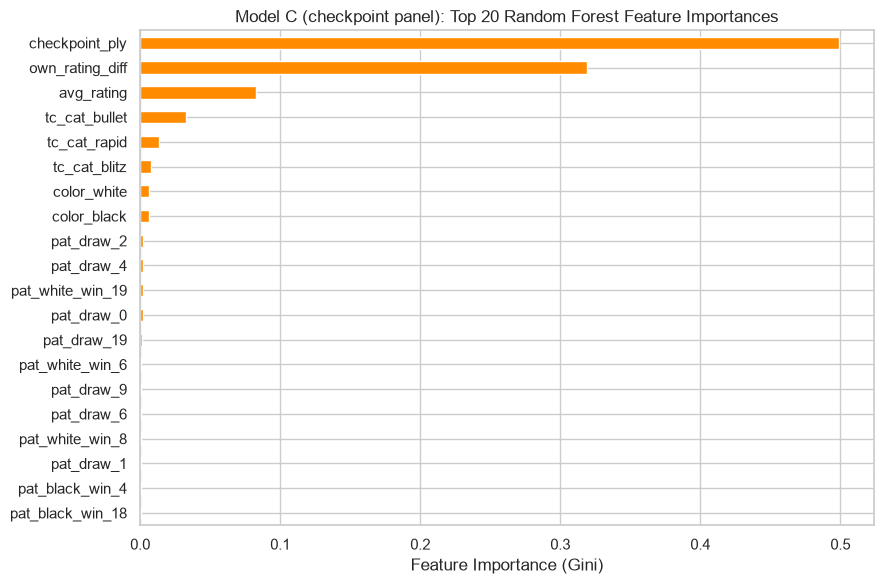

checkpoint_ply      0.499028
own_rating_diff     0.319171
avg_rating          0.082895
tc_cat_bullet       0.032472
tc_cat_rapid        0.013403
tc_cat_blitz        0.007578
color_white         0.006558
color_black         0.006420
pat_draw_2          0.002233
pat_draw_4          0.002178
pat_white_win_19    0.001918
pat_draw_0          0.001786
pat_draw_19         0.000960
pat_white_win_6     0.000787
pat_draw_9          0.000777
pat_draw_6          0.000726
pat_white_win_8     0.000721
pat_draw_1          0.000719
pat_black_win_4     0.000692
pat_black_win_18    0.000647
dtype: float64

In [48]:
# Top 20 RF feature importances -- pattern flags competing directly against
# rating/checkpoint/color for the model's attention
cat_names_c = checkpoint_preprocessor.named_transformers_['cat'].get_feature_names_out(CP_CAT).tolist()
feature_names_c = CP_NUM + cat_names_c + pattern_cols
feat_imp_c = pd.Series(rf_c.feature_importances_, index=feature_names_c).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 6))
feat_imp_c.head(20).plot(kind='barh', ax=ax, color='darkorange')
ax.invert_yaxis()
ax.set_xlabel('Feature Importance (Gini)')
ax.set_title('Model C (checkpoint panel): Top 20 Random Forest Feature Importances')
plt.tight_layout()
plt.show()

feat_imp_c.head(20)

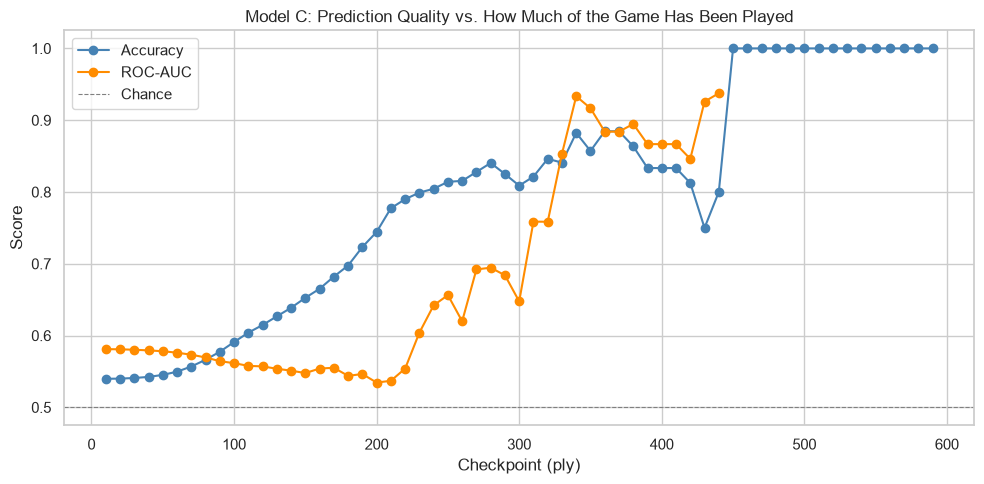

,checkpoint_ply,n,accuracy,roc_auc
0,10,1968846.0,0.539757,0.581088
1,20,1907038.0,0.539999,0.580815
2,30,1792718.0,0.540861,0.580231
3,40,1610090.0,0.542373,0.579303
4,50,1356090.0,0.545177,0.578140
5,60,1060670.0,0.549648,0.576130
6,70,785838.0,0.556863,0.573284
7,80,564984.0,0.566236,0.569518
8,90,397522.0,0.577410,0.564292
9,100,273010.0,0.590938,0.561542


In [49]:
# The payoff: does prediction accuracy actually improve the more of the game
# that's been observed? Slice the exhaustively-scored test set by checkpoint_ply.
by_checkpoint = eval_df.groupby('checkpoint_ply').apply(
    lambda g: pd.Series({
        'n': len(g),
        'accuracy': accuracy_score(g['y_true'], g['y_pred_rf']),
        'roc_auc': roc_auc_score(g['y_true'], g['y_prob_rf']) if g['y_true'].nunique() > 1 else np.nan,
    })
).reset_index()

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(by_checkpoint['checkpoint_ply'], by_checkpoint['accuracy'], marker='o', label='Accuracy', color='steelblue')
ax.plot(by_checkpoint['checkpoint_ply'], by_checkpoint['roc_auc'], marker='o', label='ROC-AUC', color='darkorange')
ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, label='Chance')
ax.set_xlabel('Checkpoint (ply)')
ax.set_ylabel('Score')
ax.set_title('Model C: Prediction Quality vs. How Much of the Game Has Been Played')
ax.legend()
plt.tight_layout()
plt.show()

by_checkpoint.head(20)

### Section 8 Recap

*To fill in after the full-dataset run:*
- Dedup counts at full scale (sample: 232 mined sequences -> 151 after containment dedup -> 151 after color-flip dedup, with zero color-flip pairs found) -- with far more mined sequences at full scale, color-flip duplicates becoming actually present (rather than zero) would be worth noting.
- The chunked/reservoir pipeline replaced the original dense in-memory panel because the dense version was projected at ~1.04B rows / ~150-300+GB at full scale -- confirm actual full-scale wall-clock time and that memory stays in the low single-digit GB range as designed (validated equivalent to the dense approach on the 50K sample: accuracy 0.554 vs. 0.553, ROC-AUC 0.579 vs. 0.579).
- Checkpoint-accuracy curve: does accuracy still climb from the sample's ~54.3% at ply 10 toward its ~61.6% (ply 120) range, and does the full dataset's much larger high-ply sample sizes resolve the noisy tail seen at the sparsest late checkpoints in the sample, or is that a real effect?
- Whether `checkpoint_ply` still outranks `avg_rating` in RF feature importance (sample: 9.4% vs. 8.3%), and whether any individual pattern flag breaks the sample's ceiling with more data behind it.
- Logistic Regression was added to Model C for the same reason it was added to Model A (Section 7) -- confirm whether it continues to slightly edge Random Forest here too (sample: LogReg 56.2% accuracy / 0.586 ROC-AUC vs. RF 55.4% / 0.579), echoing Section 7's finding that Random Forest's extra flexibility isn't earning its keep over a simple logistic model for this feature set.

---
## Section 9: Model Comparison and Multiclass Check

Model A (pre-game only, one row per player) and Model C (pre-game + `checkpoint_ply` + pattern-timing flags, many rows per player -- one per checkpoint) are compared here. They aren't directly row-comparable the way Model A/B used to be, since Model C's test set has one row per (player, checkpoint) rather than one row per player -- so the comparison has two parts: an *overall* metric across all of Model C's checkpoint rows pooled together, and a *checkpoint-sliced* view showing how Model C's accuracy moves from roughly Model A's level (early checkpoints, not much has happened yet) to well above it (late checkpoints, most of the game is visible). The same split is then repeated for the 3-class `own_result` target.

In [50]:
comparison = pd.concat([
    results_a_df.loc[['Random Forest (pre-game)']],
    results_c_df.loc[['Random Forest (checkpoint panel)']],
])
comparison

,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,
Random Forest (pre-game),0.558808,0.556020,0.406028,0.469332,0.587242
Random Forest (checkpoint panel),0.549572,0.696846,0.065490,0.119728,0.582237


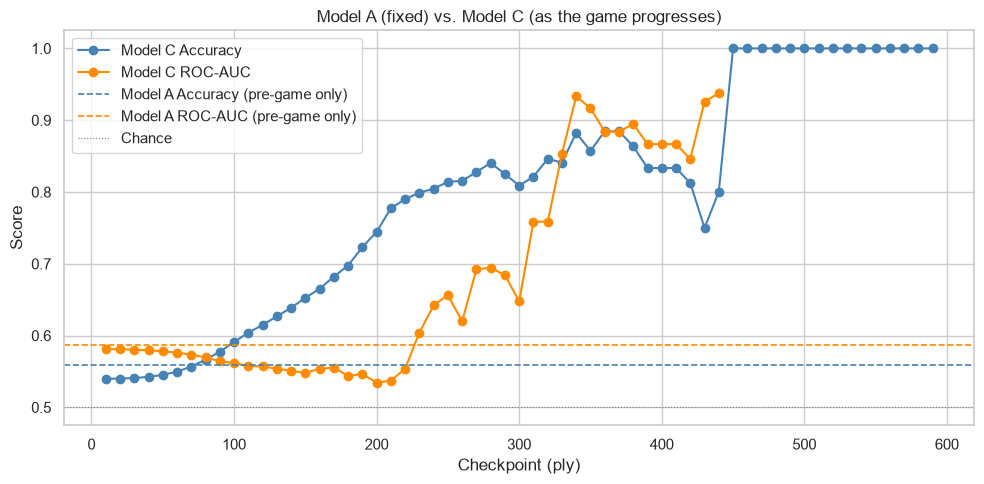

In [51]:
# Model C's accuracy/ROC-AUC by checkpoint, with Model A's fixed pre-game
# accuracy/ROC-AUC overlaid as a reference line -- this is the real comparison,
# since Model A only ever gets one shot (before the game starts) while Model C
# gets progressively more information as the game plays out
model_a_acc = results_a_df.loc['Random Forest (pre-game)', 'Accuracy']
model_a_auc = results_a_df.loc['Random Forest (pre-game)', 'ROC-AUC']

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(by_checkpoint['checkpoint_ply'], by_checkpoint['accuracy'], marker='o', label='Model C Accuracy', color='steelblue')
ax.plot(by_checkpoint['checkpoint_ply'], by_checkpoint['roc_auc'], marker='o', label='Model C ROC-AUC', color='darkorange')
ax.axhline(model_a_acc, color='steelblue', linestyle='--', linewidth=1.2, label='Model A Accuracy (pre-game only)')
ax.axhline(model_a_auc, color='darkorange', linestyle='--', linewidth=1.2, label='Model A ROC-AUC (pre-game only)')
ax.axhline(0.5, color='gray', linestyle=':', linewidth=0.8, label='Chance')
ax.set_xlabel('Checkpoint (ply)')
ax.set_ylabel('Score')
ax.set_title('Model A (fixed) vs. Model C (as the game progresses)')
ax.legend()
plt.tight_layout()
plt.show()

Multiclass (own_result) comparison:
                                             Accuracy  Precision  Recall     F1
Model                                                                          
Model A (pre-game)                             0.5361     0.5478  0.5361  0.526
Model C (checkpoint panel, all rows pooled)    0.5177     0.5214  0.5177  0.502


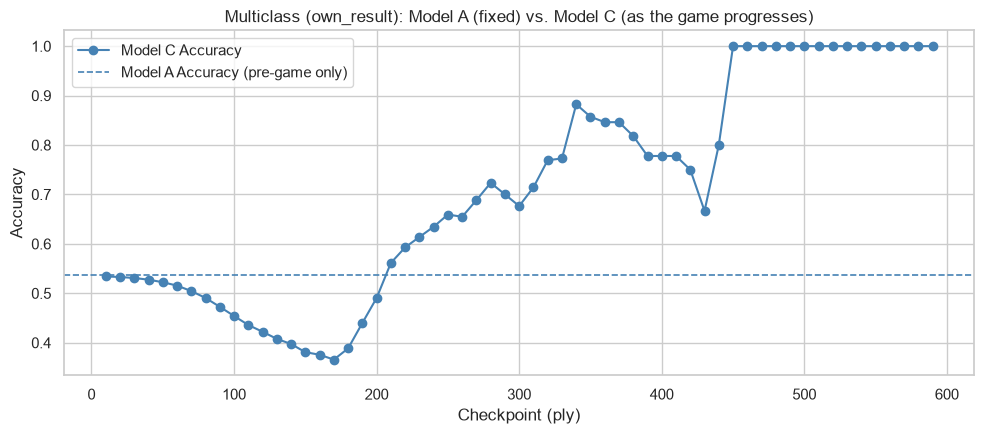

In [52]:
# Multiclass check: own_result, Model A vs Model C
def evaluate_multiclass(name, y_true, y_pred):
    return {
        'Model': name,
        'Accuracy':  accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, average='weighted', zero_division=0),
        'Recall':    recall_score(y_true, y_pred, average='weighted', zero_division=0),
        'F1':        f1_score(y_true, y_pred, average='weighted', zero_division=0),
    }

rf_a_multi = RandomForestClassifier(
    n_estimators=200, max_depth=12, min_samples_leaf=30, random_state=RANDOM_SEED, n_jobs=-1
)
rf_a_multi.fit(X_train_pg, ym_train)
ym_pred_a = rf_a_multi.predict(X_test_pg)

# Model C's multiclass RF (rf_c_multi) was already fit in Section 8 on the same
# reservoir-sampled training rows as the binary model; eval_df already carries
# its exhaustively-scored test predictions (y_true_multi/y_pred_multi) from
# Section 8's chunked scoring pass -- no re-fitting or dense panel needed here.
ymc_test = eval_df['y_true_multi']
ym_pred_c = eval_df['y_pred_multi']

multi_results = pd.DataFrame([
    evaluate_multiclass('Model A (pre-game)', ym_test, ym_pred_a),
    evaluate_multiclass('Model C (checkpoint panel, all rows pooled)', ymc_test, ym_pred_c),
]).set_index('Model')

print('Multiclass (own_result) comparison:')
print(multi_results.round(4).to_string())

# Same checkpoint-sliced view for multiclass accuracy
multi_eval_df = pd.DataFrame({
    'checkpoint_ply': eval_df['checkpoint_ply'].values,
    'y_true': ymc_test.values,
    'y_pred': ym_pred_c,
})
multi_by_checkpoint = multi_eval_df.groupby('checkpoint_ply').apply(
    lambda g: accuracy_score(g['y_true'], g['y_pred'])
).reset_index(name='accuracy')

model_a_multi_acc = accuracy_score(ym_test, ym_pred_a)
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(multi_by_checkpoint['checkpoint_ply'], multi_by_checkpoint['accuracy'], marker='o', color='steelblue', label='Model C Accuracy')
ax.axhline(model_a_multi_acc, color='steelblue', linestyle='--', linewidth=1.2, label='Model A Accuracy (pre-game only)')
ax.set_xlabel('Checkpoint (ply)')
ax.set_ylabel('Accuracy')
ax.set_title('Multiclass (own_result): Model A (fixed) vs. Model C (as the game progresses)')
ax.legend()
plt.tight_layout()
plt.show()

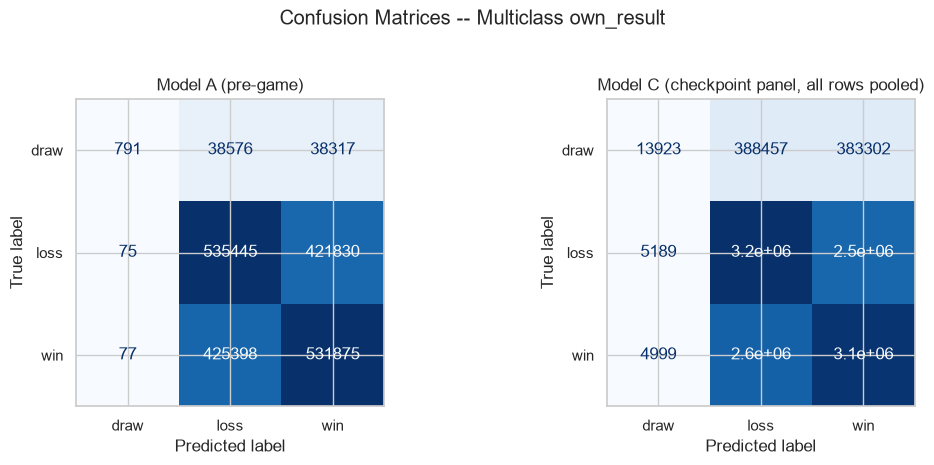

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, y_true, y_pred, title in [
    (axes[0], ym_test, ym_pred_a, 'Model A (pre-game)'),
    (axes[1], ymc_test, ym_pred_c, 'Model C (checkpoint panel, all rows pooled)'),
]:
    labels = sorted(y_true.unique())
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    ConfusionMatrixDisplay(cm, display_labels=labels).plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(title)

plt.suptitle('Confusion Matrices -- Multiclass own_result', y=1.03)
plt.tight_layout()
plt.show()

### Section 9 Recap

*To fill in after the full-dataset run:*
- Pooled Model A vs. Model C comparison, binary and multiclass -- expect the same pattern as the sample (pooled numbers slightly favor Model A, since most checkpoint-panel rows are early-game snapshots) unless the game-length distribution shifts meaningfully at full scale.
- The checkpoint-sliced comparison chart -- confirm Model C still crosses above Model A's fixed baseline, and note at what ply that crossover happens (sample: well before ply 100).
- Multiclass confusion matrices -- note which class (`win`/`loss`/`draw`) each model struggles with most, and whether that changes between Model A and Model C.

---
## Section 10: Synthesis and Key Findings

*This section carried real findings from the 50K-game sample run in the source notebook -- reset to a guided template here, since those specific numbers (lift values, accuracies, coefficients) are specific to that small sample and shouldn't be presented as this notebook's answer. Fill in each question below with the actual results from this notebook's real run (the 15-million-game random sub-sample described in the Methodology Evolution note above, not the full 84.6M-game dataset -- see that note for why); the structure and the 50K-sample numbers (in brackets) are reference points for comparison, not conclusions to carry forward unchanged.*

**1. Does rating dominate outcome prediction so strongly that move patterns add little?** *[Section 7's feature importance split between `own_rating_diff`/`avg_rating` vs. `color`/`tc_cat`; Section 8's split between `own_rating_diff`, `checkpoint_ply`, and individual pattern flags. Sample: rating features ~96% of Model A's importance; `checkpoint_ply` (9.4%) outranked every individual pattern flag in Model C.]*

**2. Does knowing you're playing White matter, independent of rating?** *[Section 7's `color_white`/`color_black` Logistic Regression coefficients. Sample: +0.048 / -0.094, a real but small effect next to rating_diff's 0.416 coefficient.]*

**3. Do move sequences that look strong overall hold up at every rating level, or are they rating-dependent?** *[Section 6's per-bin findings -- strongest sequence per bin, whether any sequence tops more than one bin. Sample: strongest was `<1000`'s white_win sequence at lift 1.329; no sequence topped more than one bin.]*

**4. Are any move sequences distinctly tied to a specific outcome, including draw?** *[Section 5's white_win/black_win/draw one-vs-rest findings. Sample: draw's `e4 c6 d4 d5 e5 Bf5` (Advance Caro-Kann) reached lift 1.922, well above white_win/black_win's ~1.2 ceiling.]*

**5. Does prediction accuracy actually improve as more of the game is observed?** *[Section 8/9's checkpoint-accuracy curve -- where it starts relative to Model A's fixed baseline, how it trends, and whether the trend holds up (or gets less noisy) at the high-ply end where the sample had very few games. Sample: 54.6% at ply 10 climbing to 62.1% at ply 130, crossing above Model A's 55.6% well before the game's midpoint.]*

**6. Where does this land relative to the preliminary results in the progress report?** *[Compare Model A's full-scale accuracy to the original pipeline notebook's leaky preliminary model (which used `num_plies` and reached 62.95% accuracy on the sample -- that specific number is sample-specific and won't be recomputed at full scale here, since Part I of this notebook no longer includes that classification section; treat it as historical context, not a full-scale baseline). State where Model C's checkpoint-panel accuracy tops out and whether/where it matches or beats that historical number using only real-time-available information.]*

### Limitations

*Update this list based on what the full run actually shows -- the sample-run version noted:*
- This run uses a random 15-million-game sub-sample, not the complete 84.6M-game file -- see the Methodology Evolution note above for the memory/cost reasoning behind that choice, and its noted caveat about the random-sampling method's slight length-based selection weighting.
- Checkpoint panel's high-ply checkpoints being built from very few games in the 50K sample -- **check whether this is resolved at 15M games**, since ~300x more games should substantially thicken the high-ply tail (a game reaching ply 200 was rare at 50K games; the *count* of such games should scale roughly linearly with total games parsed, so this run should have a genuinely large high-ply sample even though the *rate* stays the same).
- Draws being a rare (3.7%) class that's hard for a fixed binary flag to move a rating-dominated model, despite Section 5 finding a real, strong draw-associated sequence.
- State the actual sample size used for this run's results (target: 15,000,000 randomly-sampled games) and confirm it matches what PARSE_MODE was actually set to when these results were produced.